# initialize

In [16]:
import os
import sys
from pathlib import Path
import joblib
import numexpr
numexpr.set_num_threads(64)
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)
project_root = Path.cwd().parent
print(project_root)
sys.path.insert(0, str(project_root))

/home/yangjiong/CategoryLearning_gitcode


In [17]:
from src.Bayesian import *
from src.Bayesian.problems.config import config_fgt
from src.Bayesian.problems import *
from src.Bayesian.utils.optimizer import Optimizer, ConstantDict
from src.Bayesian.utils.model_evaluation import ModelEval

In [ ]:
from src.Bayesian.problems.fit_config import window_size_configs
model_name = 'M6_MH'
# 导入模型配置
from src.Bayesian.problems.fit_config import window_size_configs
if model_name == 'M0_Base':
    module_configs = {}
elif model_name == 'M1_P':
    module_configs = {"perception": (BasePerception, {})}
elif model_name == 'M2_M':
    module_configs = {"memory": (BaseMemory, {
                        "personal_memory_range": {
                            "gamma": (0.05, 1.0),
                            "w0": (0.075, 0.15)
                        },
                        "param_resolution": 20
                    })}  
elif model_name == 'M3_H':
    from src.Bayesian.problems.fit_config import module_configs_M3
    module_configs = module_configs_M3
elif model_name == 'M4_PM':
    module_configs = {
            "memory": (BaseMemory, {
                "personal_memory_range": {
                    "gamma": (0.05, 1.0),
                    "w0": (0.075, 0.15)
                },
                "param_resolution": 20
            }),
            "perception": (BasePerception, {})}    
elif model_name == 'M5_PH':
    from src.Bayesian.problems.fit_config import module_configs_M5
    module_configs = module_configs_M5
elif model_name == 'M6_MH':
    from src.Bayesian.problems.fit_config import module_configs_M6
    module_configs = module_configs_M6
elif model_name == 'M7_PMH':
    from src.Bayesian.problems.fit_config import module_configs_M7
    module_configs = module_configs_M7
# 初始化优化器
optimizer = Optimizer(module_configs, n_jobs=120)
# 导入数据
processed_path = Path(project_root) / 'data_meg' / 'processed'/'Task3b'/ 'Task3b_processed.csv'
optimizer.prepare_data(processed_path)
subIDs = [333]
result_path = Path(project_root) / 'results' / 'Model_results_sub333_260326_brier' 

Using parallel optimization for multiple subjects.


# model:M6

In [ ]:
# 执行优化
subIDs = [333]

result_path = Path(project_root) / 'results' / 'Model_results_sub333_260326_brier' 
os.makedirs(result_path, exist_ok=True)
if model_name == 'M0_Base':
    res = optimizer.optimize_params_with_subs_parallel(
        config_fgt, subIDs, window_size_configs, 1, 0)

elif model_name == 'M1_P':
    res = optimizer.optimize_params_with_subs_parallel(
        config_fgt, subIDs, window_size_configs, 0, 500)
    
elif model_name == 'M2_M':
    res = optimizer.optimize_params_with_subs_parallel(
        config_fgt, subIDs, window_size_configs, 1, 0)
    
elif model_name == 'M3_H':
    res = optimizer.optimize_params_with_subs_parallel(
        config_fgt, subIDs, window_size_configs, 0, 1000)
    
elif model_name == 'M4_PM':
    res = optimizer.optimize_params_with_subs_parallel(
        config_fgt, subIDs, window_size_configs, 3, 500)
    
elif model_name == 'M5_PH':
    res = optimizer.optimize_params_with_subs_parallel(
        config_fgt, subIDs, window_size_configs, 0, 1000)
    
elif model_name == 'M6_MH': 
    res = optimizer.optimize_params_with_subs_parallel_new(
        config_fgt, subIDs, window_size_configs, 50, 1000, objective='brier')

elif model_name == 'M7_PMH':
    res = optimizer.optimize_params_with_subs_parallel(
        config_fgt, subIDs, window_size_configs, 5, 1000)
    
    
# 保存优化结果
optimizer.save_results(res, model_name, result_path)

Processing tasks:   0%|                                                     | 0/400 [00:00<?, ?it/s]

/home/yangjiong/CategoryLearning_gitcode/logs/Run_20260326_100018.log
{'default_model': {'modules': {}, 'agenda': ['__self__']}, 'm_model': {'modules': {'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {'beta_init': 3.0, 'beta_min': 0.1, 'beta_max': 100.0, 'increase_rate': 1.15, 'decrease_rate': 0.3}}, 'likelihood_mod': {'class': 'src.Bayesian_state.problems.modules.likelihood.LikelihoodModule', 'kwargs': {}}, 'memory_mod': {'class': 'src.Bayesian_state.problems.modules.memory.DualMemoryModule', 'kwargs': {'w0': 0.8, 'gamma': 0.8}}}, 'agenda': ['likelihood_mod', 'memory_mod', 'beta_mod']}, 'base_model': {'modules': {'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {'beta_init': 3.0, 'beta_min': 0.1, 'beta_max': 100.0, 'decrease_rate': 0.5, 'correct_additive': 2.0, 'use_prior_scaling': True, 'prior_beta_scale': 10.0}}, 'likelihood_mod': {'class': 'src.Bayesian_state.problems.modules.likelihood.LikelihoodModule',

INFO:cat-learning:logger is running normally.


__', 'beta_mod']}, 'p_model': {'modules': {'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {}}, 'likelihood_mod': {'class': 'src.Bayesian_state.problems.modules.likelihood.LikelihoodModule', 'kwargs': {}}, 'perception_mod': {'class': 'src.Bayesian_state.problems.modules.perception.PerceptionModule'}}, 'agenda': ['perception_mod', 'likelihood_mod', '__self__', 'beta_mod']}, 'pmh_model': {'modules': {'perception_mod': {'class': 'src.Bayesian_state.problems.modules.perception.PerceptionModule'}, 'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {'beta_init': 1.0, 'beta_min': 0.1, 'beta_max': 100.0, 'decrease_rate': 0.2, 'correct_additive': 0.8, 'use_prior_scaling': True, 'prior_beta_scale': 5.0}}, 'hypo_transitions_mod': {'class': 'src.Bayesian_state.problems.modules.hypo_transitions.DynamicHypothesisModule', 'kwargs': {'strategies': 'original_strategies_a', 'init_num': 4}}, 'likelihood_mod': {'class': 'src.Bayesi

Processing tasks:  30%|████████████▉                              | 120/400 [00:04<00:11, 24.72it/s]INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger i

...

INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is runnin


{'default_model': {'modules': {}, 'agenda': ['__self__']}, 'm_model': {'modules': {'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {'beta_init': 3.0, 'beta_min': 0.1, 'beta_max': 100.0, 'increase_rate': 1.15, 'decrease_rate': 0.3}}, 'likelihood_mod': {'class': 'src.Bayesian_state.problems.modules.likelihood.LikelihoodModule', 'kwargs': {}}, 'memory_mod': {'class': 'src.Bayesian_state.problems.modules.memory.DualMemoryModule', 'kwargs': {'w0': 0.8, 'gamma': 0.8}}}, 'agenda': ['likelihood_mod', 'memory_mod', 'beta_mod']}, 'base_model': {'modules': {'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {'beta_init': 3.0, 'beta_min': 0.1, 'beta_max': 100.0, 'decrease_rate': 0.5, 'correct_additive': 2.0, 'use_prior_scaling': True, 'prior_beta_scale': 10.0}}, 'likelihood_mod': {'class': 'src.Bayesian_state.problems.modules.likelihood.LikelihoodModule', 'kwargs': {}}}, 'agenda': ['likelihood_mod', '__self__', 'beta_mod']

INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.


/home/yangjiong/CategoryLearning_gitcode/logs/Run_20260326_110209.log
{'default_model': {'modules': {}, 'agenda': ['__self__']}, 'm_model': {'modules': {'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {'beta_init': 3.0, 'beta_min': 0.1, 'beta_max': 100.0, 'increase_rate': 1.15, 'decrease_rate': 0.3}}, 'likelihood_mod': {'class': 'src.Bayesian_state.problems.modules.likelihood.LikelihoodModule', 'kwargs': {}}, 'memory_mod': {'class': 'src.Bayesian_state.problems.modules.memory.DualMemoryModule', 'kwargs': {'w0': 0.8, 'gamma': 0.8}}}, 'agenda': ['likelihood_mod', 'memory_mod', 'beta_mod']}, 'base_model': {'modules': {'beta_mod': {'class': 'src.Bayesian_state.problems.modules.beta.BetaModule', 'kwargs': {'beta_init': 3.0, 'beta_min': 0.1, 'beta_max': 100.0, 'decrease_rate': 0.5, 'correct_additive': 2.0, 'use_prior_scaling': True, 'prior_beta_scale': 10.0}}, 'likelihood_mod': {'class': 'src.Bayesian_state.problems.modules.likelihood.LikelihoodModule',

INFO:cat-learning:logger is running normally.
Computing error for params: 100%|██████████| 1000/1000 [03:05<00:00,  5.38it/s]
2026-03-26 11:06:18 - INFO - Results saved to /home/yangjiong/CategoryLearning_gitcode/results/Model_results_sub333_260325_brier/M6_MH.joblib


# prediction model

In [20]:
res = joblib.load(result_path / f'{model_name}.joblib')

In [21]:
# 计算预测结果
optimizer.set_results(res)
prediction = optimizer.predict_probs_with_subs_parallel(
    config_fgt, subIDs)
joblib.dump(prediction, result_path / f'{model_name}_predict_probs.joblib')

Predicting tasks: 100%|██████████████████████████████████████████████| 1/1 [00:00<00:00, 694.88it/s]


['/home/yangjiong/CategoryLearning_gitcode/results/Model_results_sub333_260325_brier/M6_MH_predict_probs.joblib']

In [22]:
prediction

{333: {'condition': 3,
  'true_choice': array([1, 2, 2, 3, 2, 4, 2, 3, 2, 4, 3, 1, 1, 2, 3, 1, 3, 1, 1, 3, 1, 1,
         4, 2, 1, 1, 4, 1, 1, 4, 3, 4, 4, 2, 2, 2, 4, 1, 4, 2, 2, 1, 4, 1,
         4, 2, 2, 3, 3, 1, 3, 1, 4, 2, 2, 3, 4, 3, 1, 2, 3, 1, 4, 1, 4, 3,
         2, 2, 1, 1, 3, 2, 3, 1, 2, 3, 3, 3, 1, 1, 2, 4, 3, 3, 2, 3, 4, 3,
         2, 2, 4, 3, 2, 1, 3, 1, 3, 2, 2, 3, 4, 3, 2, 4, 2, 1, 3, 1, 2, 4,
         2, 3, 1, 3, 3, 4, 1, 2, 2, 4, 3, 2, 1, 1, 2, 1, 3, 1, 1, 2, 2, 2,
         1, 2, 1, 3, 4, 2, 2, 2, 3, 3, 3, 3, 2, 3, 4, 3, 2, 3, 3, 3, 1, 2,
         4, 2, 4, 3, 1, 1, 2, 3, 2, 2, 2, 3, 2, 1, 3, 3, 4, 2, 1, 2, 4, 3,
         2, 3, 2, 4, 1, 3, 3, 1, 4, 3, 3, 2, 1, 4, 1, 3, 3, 3, 3, 2, 1, 1,
         4, 3, 3, 3, 4, 3, 3, 2, 3, 4, 4, 4, 2, 4, 1, 3, 3, 2, 3, 4, 1, 2,
         4, 2, 3, 3, 4, 3, 2, 3, 2, 2, 1, 3, 2, 4, 3, 3, 4, 4, 3, 3, 3, 2,
         1, 2, 4, 1, 1, 3, 2, 3, 2, 4, 1, 3, 2, 3, 1, 2, 1, 3, 2, 2, 4, 4,
         4, 3, 4, 4, 2, 4, 4, 3, 4, 2, 1, 4, 3, 3, 2, 3, 3, 1,

# -- origin(all trials)--

In [12]:
# Cell 1: imports + utilities

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import expit  # sigmoid
from scipy.stats import spearmanr, kendalltau, rankdata
from scipy.optimize import minimize

def _normalize_probs(probs, eps=1e-12):
    probs = np.asarray(probs, dtype=float)
    probs = np.clip(probs, 0.0, None)
    s = probs.sum(axis=1, keepdims=True)
    s = np.clip(s, eps, None)
    return probs / s

def _ensure_choice_0based(choice, n_options):
    choice = np.asarray(choice)
    u = np.unique(choice)
    # accept 1..K or 0..K-1
    if u.min() == 1 and u.max() == n_options:
        return choice.astype(int) - 1
    if u.min() == 0 and u.max() == n_options - 1:
        return choice.astype(int)
    raise ValueError(f"choice values unexpected: min={u.min()}, max={u.max()} (expect 0..{n_options-1} or 1..{n_options})")

def entropy_conf(probs, eps=1e-12):
    """Return normalized certainty = 1 - H(p)/log(K), in [0,1]."""
    p = np.clip(probs, eps, 1.0)
    H = -np.sum(p * np.log(p), axis=1)  # nats
    K = probs.shape[1]
    H_norm = H / np.log(K)
    return 1.0 - H_norm

def compute_conf_dict(choice, probs, alpha=0.5, eps=1e-12):
    """
    Build multiple model-confidence candidates.
    Inputs:
      - choice: subject-chosen option (0..K-1 or 1..K)
      - probs: model distribution over K options, shape (n_trials, K)
    Returns:
      dict[name] -> conf array (n_trials,)
    """
    probs = _normalize_probs(probs, eps=eps)
    n, K = probs.shape
    c0 = _ensure_choice_0based(choice, K)

    p_star = probs[np.arange(n), c0]  # prob assigned to subject choice

    # competitor (best alternative)
    probs_other = probs.copy()
    probs_other[np.arange(n), c0] = -np.inf
    p2 = np.max(probs_other, axis=1)
    p2 = np.clip(p2, eps, 1.0)

    margin = p_star - p2
    log_margin = np.log(np.clip(p_star, eps, 1.0)) - np.log(p2)

    ent_conf = entropy_conf(probs, eps=eps)  # higher => more certain overall

    composite = alpha * log_margin + (1 - alpha) * ent_conf

    return {
        "p_star": p_star,
        "margin": margin,
        "log_margin": log_margin,
        "entropy_conf": ent_conf,
        "composite": composite,
    }

def rank_metrics(rating, conf):
    """Spearman & Kendall between ordinal rating (1..6) and continuous conf."""
    rating = np.asarray(rating, dtype=float)
    conf = np.asarray(conf, dtype=float)
    sp = spearmanr(rating, conf).correlation
    kd = kendalltau(rating, conf).correlation
    return float(sp), float(kd)

def c_index(rating, conf, max_pairs=200000, seed=0):
    """
    Concordance index for ordinal target:
      probability that (rating_i > rating_j) matches (conf_i > conf_j)
    Uses random pair sampling if needed (fast & stable).
    """
    r = np.asarray(rating, dtype=float)
    c = np.asarray(conf, dtype=float)
    n = len(r)

    rng = np.random.default_rng(seed)
    # sample pairs
    if n * (n - 1) // 2 <= max_pairs:
        # all pairs
        ii, jj = np.triu_indices(n, k=1)
    else:
        ii = rng.integers(0, n, size=max_pairs)
        jj = rng.integers(0, n, size=max_pairs)
        mask = ii != jj
        ii, jj = ii[mask], jj[mask]

    dr = r[ii] - r[jj]
    dc = c[ii] - c[jj]

    # only pairs with different ratings count
    valid = dr != 0
    dr, dc = dr[valid], dc[valid]
    if dr.size == 0:
        return np.nan

    concordant = np.sum((dr > 0) & (dc > 0)) + np.sum((dr < 0) & (dc < 0))
    discordant = np.sum((dr > 0) & (dc < 0)) + np.sum((dr < 0) & (dc > 0))
    ties = dr.size - concordant - discordant  # conf ties counted as neither

    # common definition: ties count as 0.5
    return float((concordant + 0.5 * ties) / dr.size)

print("✅ Cell 1 ready")

✅ Cell 1 ready


In [13]:
# Cell 2: inputs (replace with your data)
df = pd.read_csv(processed_path)
rating = df['rating']
choice = df['choice']
probs = prediction[333]['pred_probs']
pred_choice = prediction[333]['pred_choice']
top1_choice = prediction[333]['top1_choice']


# choice: (n_trials,) values in {1,2,3,4} or {0,1,2,3}
# rating: (n_trials,) values in {1,2,3,4,5,6}
# probs:  (n_trials,4) model distribution over options

choice = np.asarray(choice)
rating = np.asarray(rating)
probs  = np.asarray(probs, dtype=float)

assert probs.ndim == 2 and probs.shape[1] == 4, f"probs must be (n_trials,4), got {probs.shape}"
assert len(choice) == len(rating) == len(probs), "choice/rating/probs length mismatch"
assert np.all((rating >= 1) & (rating <= 6)), "rating must be in 1..6"

print("✅ Cell 2 ok")
print("n_trials:", len(rating))
print("choice unique:", np.unique(choice))
print("rating unique:", np.unique(rating))
print("pred_choice unique:", np.unique(pred_choice))
print("top1_choice unique:", np.unique(top1_choice))

✅ Cell 2 ok
n_trials: 360
choice unique: [1 2 3 4]
rating unique: [1 2 3 4 5]
pred_choice unique: [0 1 2 3 4]
top1_choice unique: [0 1 2 3 4]


In [14]:
true_choice = np.asarray(choice)         # 真实 choice 序列
pred1_choice = np.asarray(pred_choice)   # 预测序列 1
pred2_choice = np.asarray(top1_choice)   # 预测序列 2

assert len(true_choice) == len(pred1_choice) == len(pred2_choice) == 360, \
    f"length mismatch: {len(true_choice)}, {len(pred1_choice)}, {len(pred2_choice)}"

# 1) 去掉第一个试次NaN
true_choice = true_choice[1:]
pred1_choice = pred1_choice[1:]
pred2_choice = pred2_choice[1:]

# 2) 去掉仍然缺失/非法的 trial（保险）
valid = np.isfinite(true_choice) & np.isfinite(pred1_choice) & np.isfinite(pred2_choice)
valid &= np.isin(true_choice, [1,2,3,4]) & np.isin(pred1_choice, [1,2,3,4]) & np.isin(pred2_choice, [1,2,3,4])

true_choice = true_choice[valid].astype(int)
pred1_choice = pred1_choice[valid].astype(int)
pred2_choice = pred2_choice[valid].astype(int)

n = len(true_choice)
print("✅ After cleaning, n_trials =", n)
print("unique true:", np.unique(true_choice))
print("unique pred1:", np.unique(pred1_choice))
print("unique pred2:", np.unique(pred2_choice))

# trial 轴（原始试次编号从 1..360；我们去掉了第1个，所以起点是2）
# 再考虑 valid mask 后，trial 编号会有跳（但多数情况下 valid 全 True）
trial_id = np.arange(2, 361)[valid]

✅ After cleaning, n_trials = 359
unique true: [1 2 3 4]
unique pred1: [1 2 3 4]
unique pred2: [1 2 3 4]


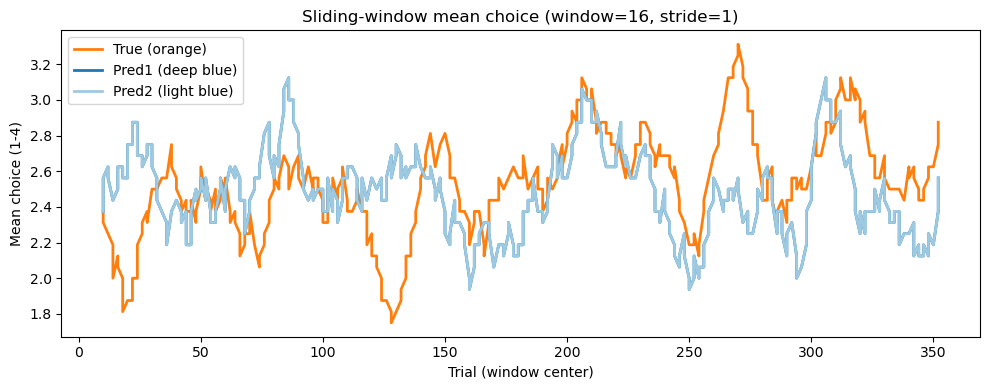

In [15]:
import matplotlib.pyplot as plt

def moving_average(x, window=16, stride=1, center=True):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < window:
        raise ValueError(f"n={n} < window={window}")
    starts = np.arange(0, n - window + 1, stride)
    avgs = np.array([x[s:s+window].mean() for s in starts])
    if center:
        pos = starts + (window - 1) / 2
    else:
        pos = starts + (window - 1)
    return pos, avgs

window = 16
stride = 1

x_pos, true_ma = moving_average(true_choice, window=window, stride=stride, center=True)
_, pred1_ma = moving_average(pred1_choice, window=window, stride=stride, center=True)
_, pred2_ma = moving_average(pred2_choice, window=window, stride=stride, center=True)

# 把 x_pos 映射到 trial 编号（用窗口中心对应的 trial_id）
center_trial = trial_id[np.round(x_pos).astype(int)]

plt.figure(figsize=(10, 4))
plt.plot(center_trial, true_ma,  color="#ff7f0e", linewidth=2, label="True (orange)")
plt.plot(center_trial, pred1_ma, color="#1f77b4", linewidth=2, label="Pred1 (deep blue)")
plt.plot(center_trial, pred2_ma, color="#9ecae1", linewidth=2, label="Pred2 (light blue)")

plt.xlabel("Trial (window center)")
plt.ylabel("Mean choice (1-4)")
plt.title(f"Sliding-window mean choice (window={window}, stride={stride})")
plt.legend()
plt.tight_layout()
plt.show()


=== Pred1 (pred_choice) vs True ===
Overall accuracy: 0.3983286908077994
Cohen's kappa: 0.19823815875182227
Macro-F1: 0.3958592640778656
Per-class accuracy: {1: 0.4305555555555556, 2: 0.40816326530612246, 3: 0.38392857142857145, 4: 0.37662337662337664}
Confusion matrix (rows=true 1-4, cols=pred 1-4):
 [[31 13 14 14]
 [28 40 11 19]
 [23 20 43 26]
 [12 13 23 29]]

=== Pred2 (top1_choice) vs True ===
Overall accuracy: 0.3983286908077994
Cohen's kappa: 0.19823815875182227
Macro-F1: 0.3958592640778656
Per-class accuracy: {1: 0.4305555555555556, 2: 0.40816326530612246, 3: 0.38392857142857145, 4: 0.37662337662337664}
Confusion matrix (rows=true 1-4, cols=pred 1-4):
 [[31 13 14 14]
 [28 40 11 19]
 [23 20 43 26]
 [12 13 23 29]]


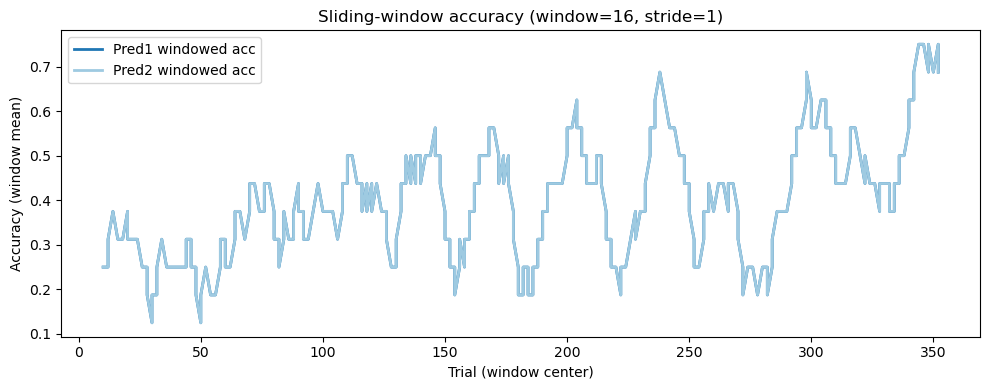

In [16]:
import numpy as np

def confusion_matrix_4(y_true, y_pred, n_classes=4):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t-1, p-1] += 1
    return cm

def cohen_kappa_from_cm(cm):
    n = cm.sum()
    if n == 0:
        return np.nan
    po = np.trace(cm) / n
    row = cm.sum(axis=1) / n
    col = cm.sum(axis=0) / n
    pe = np.sum(row * col)
    if 1 - pe < 1e-12:
        return np.nan
    return (po - pe) / (1 - pe)

def macro_f1_from_cm(cm):
    # class-wise precision/recall/f1 then average
    f1s = []
    for k in range(cm.shape[0]):
        tp = cm[k, k]
        fp = cm[:, k].sum() - tp
        fn = cm[k, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0
        f1s.append(f1)
    return float(np.mean(f1s))

def sliding_accuracy(y_true, y_pred, window=16, stride=1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    starts = np.arange(0, n - window + 1, stride)
    acc = np.array([(y_true[s:s+window] == y_pred[s:s+window]).mean() for s in starts])
    pos = starts + (window - 1) / 2
    return pos, acc

def evaluate(y_true, y_pred, name="Pred"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    acc = float((y_true == y_pred).mean())
    cm = confusion_matrix_4(y_true, y_pred, n_classes=4)
    kappa = float(cohen_kappa_from_cm(cm))
    mf1 = float(macro_f1_from_cm(cm))

    # per-class accuracy (optional)
    per_class_acc = {}
    for c in [1,2,3,4]:
        mask = (y_true == c)
        per_class_acc[c] = float((y_pred[mask] == c).mean()) if mask.any() else np.nan

    print(f"\n=== {name} vs True ===")
    print("Overall accuracy:", acc)
    print("Cohen's kappa:", kappa)
    print("Macro-F1:", mf1)
    print("Per-class accuracy:", per_class_acc)
    print("Confusion matrix (rows=true 1-4, cols=pred 1-4):\n", cm)

    return {"acc": acc, "kappa": kappa, "macro_f1": mf1, "cm": cm}

res1 = evaluate(true_choice, pred1_choice, name="Pred1 (pred_choice)")
res2 = evaluate(true_choice, pred2_choice, name="Pred2 (top1_choice)")

# （可选）滑窗准确率曲线：用同一个 window=16
window = 16
stride = 1
pos1, acc1 = sliding_accuracy(true_choice, pred1_choice, window=window, stride=stride)
pos2, acc2 = sliding_accuracy(true_choice, pred2_choice, window=window, stride=stride)

# 映射到 trial 编号（用窗口中心）
center_trial_acc = trial_id[np.round(pos1).astype(int)]  # pos1/pos2 相同长度

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(center_trial_acc, acc1, color="#1f77b4", linewidth=2, label="Pred1 windowed acc")
plt.plot(center_trial_acc, acc2, color="#9ecae1", linewidth=2, label="Pred2 windowed acc")
plt.xlabel("Trial (window center)")
plt.ylabel("Accuracy (window mean)")
plt.title(f"Sliding-window accuracy (window={window}, stride={stride})")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Cell (Fix-B): replace invalid probs rows with uniform distribution, then renormalize

import numpy as np

probs = np.asarray(probs, dtype=float)
bad = np.any(~np.isfinite(probs), axis=1)

print("invalid-probs trials:", int(bad.sum()), "/", len(bad))

# replace
if bad.any():
    probs[bad] = 1.0 / probs.shape[1]

# renormalize
row_sum = probs.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = probs.shape[1]  # avoid divide-by-zero
probs = probs / row_sum

print("after repair:")
print("  probs finite:", np.isfinite(probs).all())
print("  row_sum min/max:", probs.sum(axis=1).min(), probs.sum(axis=1).max())

invalid-probs trials: 1 / 360
after repair:
  probs finite: True
  row_sum min/max: 0.9999999999999998 1.0000000000000002


In [18]:
# Cell 1: get probability assigned to subject's true choice (p_star)

import numpy as np

choice = np.asarray(choice).astype(int)      # 1..4
probs = np.asarray(probs, dtype=float)       # (n_trials, 4)

assert probs.ndim == 2 and probs.shape[1] == 4
assert len(choice) == probs.shape[0]

# 去掉第一个trial（你说缺失）
choice2 = choice[1:]
probs2 = probs[1:, :]

# 防 NaN / 非法概率（可选但推荐）
valid = np.isfinite(choice2) & np.all(np.isfinite(probs2), axis=1)
valid &= np.isin(choice2, [1,2,3,4])

choice2 = choice2[valid]
probs2 = probs2[valid]

# 归一化（防止行和不为1）
row_sum = probs2.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = 1.0
probs2 = probs2 / row_sum

# p_star: P_model(choice_subject)
p_star = probs2[np.arange(len(choice2)), choice2 - 1]

print("✅ p_star computed:", p_star.shape, "range:", p_star.min(), p_star.max())

✅ p_star computed: (359,) range: 7.27755535830127e-05 0.9814534554210936


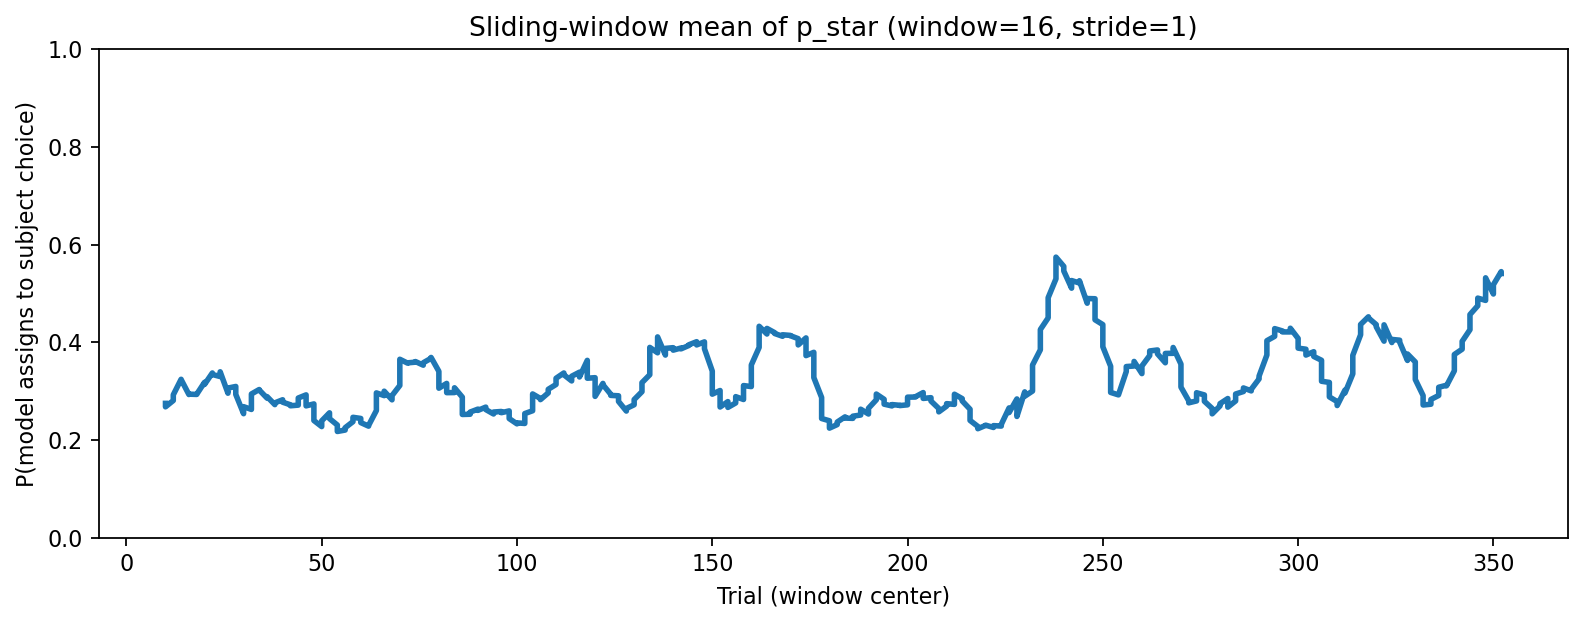

In [19]:
# Cell 2: sliding-window plot of p_star

import numpy as np
import matplotlib.pyplot as plt

def moving_average(x, window=16, stride=1, center=True):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < window:
        raise ValueError(f"n={n} < window={window}")
    starts = np.arange(0, n - window + 1, stride)
    avgs = np.array([x[s:s+window].mean() for s in starts])
    pos = starts + (window - 1) / 2 if center else starts + (window - 1)
    return pos, avgs

window = 16
stride = 1  # 滑窗；如果想更清晰改成 16

x_pos, p_star_ma = moving_average(p_star, window=window, stride=stride, center=True)


trial_id = np.arange(2, 2 + len(p_star))  # 如果你不需要精确映射到原trial编号

center_trial = trial_id[np.round(x_pos).astype(int)]

plt.figure(figsize=(10, 4), dpi=160)
plt.plot(center_trial, p_star_ma, linewidth=2.5)
plt.ylim(0, 1)
plt.xlabel("Trial (window center)")
plt.ylabel("P(model assigns to subject choice)")
plt.title(f"Sliding-window mean of p_star (window={window}, stride={stride})")
plt.tight_layout()
plt.show()

In [20]:
# Cell 3: compute confidence candidates

alpha = 0.5  # composite 权重：log_margin vs entropy_conf
conf_dict = compute_conf_dict(choice=choice, probs=probs, alpha=alpha)

print("✅ Cell 3 ok. Conf candidates:")
for k, v in conf_dict.items():
    v = np.asarray(v)
    print(f"{k:12s}  shape={v.shape}  min={v.min():.4g}  max={v.max():.4g}")

✅ Cell 3 ok. Conf candidates:
p_star        shape=(360,)  min=7.278e-05  max=0.9815
margin        shape=(360,)  min=-0.9615  max=0.9683
log_margin    shape=(360,)  min=-9.442  max=4.315
entropy_conf  shape=(360,)  min=0  max=0.9243
composite     shape=(360,)  min=-4.336  max=2.62


In [21]:
# Cell 3b: add top1-based conf + compute agree/disagree

import numpy as np

# choice 是 1-4，这里转成 0-3
choice0 = np.asarray(choice).astype(int) - 1

# top1 index and confidence
top1_idx = np.argmax(probs, axis=1)                 # 0..3
conf_top1 = np.max(probs, axis=1)                   # max prob

# top1 margin = top1 - second best
sorted_probs = np.sort(probs, axis=1)
conf_top1_margin = sorted_probs[:, -1] - sorted_probs[:, -2]

# whether model top1 agrees with subject choice
agree = (top1_idx == choice0)

# merge into conf_dict (no need to modify compute_conf_dict)
conf_dict = dict(conf_dict)  # ensure it's mutable
conf_dict["top1"] = conf_top1
conf_dict["top1_margin"] = conf_top1_margin

print("✅ Cell 3b done")
print("agree rate:", agree.mean(), f"({agree.sum()}/{len(agree)})")
print("top1 range:", conf_top1.min(), conf_top1.max())
print("top1_margin range:", conf_top1_margin.min(), conf_top1_margin.max())

✅ Cell 3b done
agree rate: 0.4 (144/360)
top1 range: 0.25 0.9814534554210936
top1_margin range: 0.0 0.9683385088009634


In [22]:
# Cell 4: rank-based evaluation (no mapping needed)

rank_results = {}
for name, conf in conf_dict.items():
    sp, kd = rank_metrics(rating, conf)
    ci = c_index(rating, conf, max_pairs=200000, seed=0)
    rank_results[name] = {"spearman": sp, "kendall": kd, "c_index": ci}

rank_df = pd.DataFrame(rank_results).T.sort_values("spearman", ascending=False)
print("✅ Cell 4 done: rank metrics\n")
display(rank_df)

✅ Cell 4 done: rank metrics



,spearman,kendall,c_index
composite,0.164203,0.125552,0.575701
log_margin,0.158600,0.121484,0.573248
margin,0.157420,0.120589,0.572708
p_star,0.146772,0.112154,0.567622
entropy_conf,-0.025484,-0.019594,0.488186
top1_margin,-0.026324,-0.020751,0.487488
top1,-0.028117,-0.022319,0.486543


n_agree: 144 n_disagree: 216
mean rating | agree: 2.2569444444444446 disagree: 1.8888888888888888
median rating | agree: 2.0 disagree: 2.0
Mann–Whitney U p-value: 0.006026016711877504
Cohen's d (agree - disagree): 0.36163426623814476


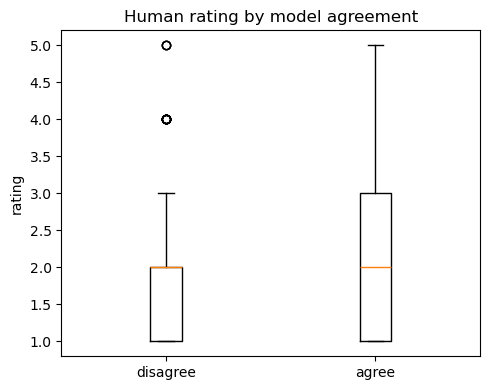

In [23]:
# Cell 4b: agree vs disagree rating analysis

import numpy as np
from scipy.stats import mannwhitneyu

r = np.asarray(rating).astype(float)
r_agree = r[agree]
r_dis = r[~agree]

print("n_agree:", len(r_agree), "n_disagree:", len(r_dis))
print("mean rating | agree:", r_agree.mean(), "disagree:", r_dis.mean())
print("median rating | agree:", np.median(r_agree), "disagree:", np.median(r_dis))

# Mann–Whitney U (non-parametric)
if len(r_agree) > 0 and len(r_dis) > 0:
    u = mannwhitneyu(r_agree, r_dis, alternative="two-sided")
    print("Mann–Whitney U p-value:", u.pvalue)

# Simple effect size: Cohen's d (treat rating as numeric)
def cohens_d(a, b):
    a = np.asarray(a); b = np.asarray(b)
    na, nb = len(a), len(b)
    va, vb = a.var(ddof=1), b.var(ddof=1)
    sp = np.sqrt(((na-1)*va + (nb-1)*vb) / max(na+nb-2, 1))
    return (a.mean() - b.mean()) / (sp + 1e-12)

if len(r_agree) > 1 and len(r_dis) > 1:
    print("Cohen's d (agree - disagree):", cohens_d(r_agree, r_dis))

# quick boxplot
import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))
plt.boxplot([r_dis, r_agree], labels=["disagree", "agree"])
plt.ylabel("rating")
plt.title("Human rating by model agreement")
plt.tight_layout()
plt.show()

In [24]:
# Cell 5: ordered logit link (evaluation-only) + CV ordinal NLL

def _pack_thresholds(theta1, deltas):
    """theta_j strictly increasing via theta1 + cumulative exp(deltas)."""
    thetas = [theta1]
    cur = theta1
    for d in deltas:
        cur = cur + np.exp(d)
        thetas.append(cur)
    return np.array(thetas)  # length = (n_classes-1)

def ordered_logit_negloglik(params, x, y, n_classes=6, eps=1e-12):
    """
    Cumulative logit:
      P(y <= k) = sigmoid(theta_k - a*x), k=1..K-1
    y in {1..K}
    """
    a = params[0]
    theta1 = params[1]
    deltas = params[2:]  # length K-2
    thetas = _pack_thresholds(theta1, deltas)  # length K-1

    z = a * x
    # cumulative probs for k=1..K-1
    cdf = expit(thetas[None, :] - z[:, None])  # (n, K-1)

    # convert to class probs
    # p1 = cdf1
    # pk = cdfk - cdf(k-1)
    # pK = 1 - cdf(K-1)
    n = len(x)
    p = np.empty((n, n_classes), dtype=float)
    p[:, 0] = cdf[:, 0]
    for k in range(1, n_classes - 1):
        p[:, k] = cdf[:, k] - cdf[:, k - 1]
    p[:, -1] = 1.0 - cdf[:, -1]
    p = np.clip(p, eps, 1.0)

    # NLL
    idx = (y.astype(int) - 1)
    return -np.mean(np.log(p[np.arange(n), idx]))

def fit_ordered_logit(x, y, n_classes=6):
    """
    Fit ordered logit on (x,y) using MLE.
    Returns fitted params and a predict_proba function.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=int)

    # init params:
    # slope a ~ 1
    # thresholds roughly match quantiles of x (heuristic)
    qs = np.quantile(x, np.linspace(1/n_classes, (n_classes-1)/n_classes, n_classes-1))
    # set theta_k ≈ a*q
    a0 = 1.0
    thetas0 = qs * a0
    theta1_0 = thetas0[0]
    # deltas in unconstrained space: exp(d) adds positive gaps
    gaps = np.diff(thetas0)
    gaps = np.clip(gaps, 1e-2, None)
    deltas0 = np.log(gaps)
    p0 = np.concatenate([[a0, theta1_0], deltas0])

    res = minimize(
        ordered_logit_negloglik, p0,
        args=(x, y, n_classes),
        method="L-BFGS-B"
    )
    if not res.success:
        # still return best found
        pass
    params_hat = res.x

    def predict_proba(x_new, eps=1e-12):
        x_new = np.asarray(x_new, dtype=float)
        a = params_hat[0]
        theta1 = params_hat[1]
        deltas = params_hat[2:]
        thetas = _pack_thresholds(theta1, deltas)

        z = a * x_new
        cdf = expit(thetas[None, :] - z[:, None])

        n = len(x_new)
        p = np.empty((n, n_classes), dtype=float)
        p[:, 0] = cdf[:, 0]
        for k in range(1, n_classes - 1):
            p[:, k] = cdf[:, k] - cdf[:, k - 1]
        p[:, -1] = 1.0 - cdf[:, -1]
        return np.clip(p, eps, 1.0)

    return params_hat, predict_proba, res

def cv_ordinal_nll(conf, rating, n_folds=5, seed=0, n_classes=6):
    conf = np.asarray(conf, dtype=float)
    rating = np.asarray(rating, dtype=int)
    n = len(conf)
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    folds = np.array_split(idx, n_folds)

    fold_nlls = []
    for f in range(n_folds):
        test_idx = folds[f]
        train_idx = np.concatenate([folds[j] for j in range(n_folds) if j != f])

        x_tr, y_tr = conf[train_idx], rating[train_idx]
        x_te, y_te = conf[test_idx], rating[test_idx]

        params_hat, predict_proba, res = fit_ordered_logit(x_tr, y_tr, n_classes=n_classes)
        p_te = predict_proba(x_te)
        nll = -np.mean(np.log(p_te[np.arange(len(y_te)), y_te - 1]))
        fold_nlls.append(float(nll))

    return float(np.mean(fold_nlls)), fold_nlls

# run CV-NLL for each conf metric
n_folds = 5
seed = 0

ord_results = {}
for name, conf in conf_dict.items():
    mean_nll, fold_nlls = cv_ordinal_nll(conf, rating, n_folds=n_folds, seed=seed, n_classes=6)
    ord_results[name] = {"ordinal_nll_cv_mean": mean_nll, "ordinal_nll_cv_folds": fold_nlls}

ord_df = pd.DataFrame(ord_results).T.sort_values("ordinal_nll_cv_mean", ascending=True)
print("✅ Cell 5 done: CV ordinal NLL (lower is better)\n")
display(ord_df)

✅ Cell 5 done: CV ordinal NLL (lower is better)



,ordinal_nll_cv_mean,ordinal_nll_cv_folds
log_margin,1.300569,"[1.3016350597519504, 1.3364548735163844, 1.265..."
composite,1.301682,"[1.301647512649165, 1.33799929974501, 1.269310..."
margin,1.302964,"[1.3006194774138728, 1.3443678760683013, 1.266..."
p_star,1.305073,"[1.298532483907569, 1.345952760431582, 1.27590..."
top1,1.312888,"[1.2853508427691014, 1.3529063674561312, 1.276..."
entropy_conf,1.313133,"[1.2861698436864337, 1.3554626997915291, 1.275..."
top1_margin,1.313277,"[1.2853465564334148, 1.3531277614956352, 1.277..."


In [25]:
# Cell 5b: rerun evaluation for updated conf_dict

import pandas as pd
import numpy as np


R = int(np.max(rating))
print("Using n_rating_classes =", R)

# --- rank metrics ---
rank_results = {}
for name, conf in conf_dict.items():
    conf = np.asarray(conf, dtype=float)
    sp = spearmanr(rating, conf).correlation
    kd = kendalltau(rating, conf).correlation
    ci = c_index(rating, conf, max_pairs=200000, seed=0)
    rank_results[name] = {"spearman": float(sp), "kendall": float(kd), "c_index": float(ci)}

rank_df = pd.DataFrame(rank_results).T.sort_values("spearman", ascending=False)

# --- ordinal NLL (CV) ---
ord_results = {}
for name, conf in conf_dict.items():
    conf = np.asarray(conf, dtype=float)
    mean_nll, fold_nlls = cv_ordinal_nll(conf, rating, n_folds=5, seed=0, n_classes=R)
    ord_results[name] = {"ordinal_nll_cv_mean": mean_nll, "ordinal_nll_cv_folds": fold_nlls}

ord_df = pd.DataFrame(ord_results).T.sort_values("ordinal_nll_cv_mean", ascending=True)

summary = rank_df.join(ord_df, how="left")
summary = summary.sort_values(["ordinal_nll_cv_mean", "spearman"], ascending=[True, False])

print("✅ Updated summary\n")
display(summary)

Using n_rating_classes = 5
✅ Updated summary



,spearman,kendall,c_index,ordinal_nll_cv_mean,ordinal_nll_cv_folds
log_margin,0.158600,0.121484,0.573248,1.30057,"[1.3016362254402485, 1.3364547457511107, 1.265..."
composite,0.164203,0.125552,0.575701,1.301681,"[1.3016495024287282, 1.337990597052431, 1.2693..."
margin,0.157420,0.120589,0.572708,1.302967,"[1.3006170728613176, 1.3443711364714328, 1.266..."
p_star,0.146772,0.112154,0.567622,1.305073,"[1.2985256406525103, 1.3459519004543143, 1.275..."
top1,-0.028117,-0.022319,0.486543,1.312885,"[1.285342332682636, 1.3529004202048174, 1.2763..."
entropy_conf,-0.025484,-0.019594,0.488186,1.313135,"[1.2861721562271922, 1.3554646768717076, 1.275..."
top1_margin,-0.026324,-0.020751,0.487488,1.313274,"[1.2853443088210244, 1.353131734337985, 1.2770..."


In [26]:
# Cell 6: summary table + plot

summary = rank_df.join(ord_df, how="left")
summary = summary.sort_values(["ordinal_nll_cv_mean", "spearman"], ascending=[True, False])
print("✅ Summary (sorted by CV ordinal NLL, then Spearman)\n")
display(summary)

# --- plot: 2x2 subplots for the top 4 conf metrics (by Spearman or by NLL) ---
top4 = list(summary.index[:4])

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.ravel()

for ax, name in zip(axes, top4):
    conf = np.asarray(conf_dict[name], dtype=float)
    ax.scatter(conf, rating, s=8, alpha=0.35)
    ax.set_title(f"{name} | ρ={summary.loc[name,'spearman']:.3f}, NLL={summary.loc[name,'ordinal_nll_cv_mean']:.3f}")
    ax.set_xlabel("conf (model)")
    ax.set_ylabel("rating (human)")

    # binned mean (visual only): quantile bins on conf
    n_bins = 10
    edges = np.quantile(conf, np.linspace(0, 1, n_bins + 1))
    # make strictly increasing
    for i in range(1, len(edges)):
        if edges[i] <= edges[i-1]:
            edges[i] = edges[i-1] + 1e-12
    bin_id = np.digitize(conf, edges[1:-1])  # 0..n_bins-1

    centers, means = [], []
    for b in range(n_bins):
        m = rating[bin_id == b]
        if len(m) == 0:
            continue
        centers.append(np.median(conf[bin_id == b]))
        means.append(np.mean(m))
    if len(centers) >= 2:
        ax.plot(centers, means, linewidth=2)

for j in range(len(top4), 4):
    axes[j].axis("off")

plt.tight_layout()
out_png = "rating_vs_conf_compare.png"
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.close()
print("✅ Plot saved:", out_png)

✅ Summary (sorted by CV ordinal NLL, then Spearman)



,spearman,kendall,c_index,ordinal_nll_cv_mean,ordinal_nll_cv_folds
log_margin,0.158600,0.121484,0.573248,1.30057,"[1.3016362254402485, 1.3364547457511107, 1.265..."
composite,0.164203,0.125552,0.575701,1.301681,"[1.3016495024287282, 1.337990597052431, 1.2693..."
margin,0.157420,0.120589,0.572708,1.302967,"[1.3006170728613176, 1.3443711364714328, 1.266..."
p_star,0.146772,0.112154,0.567622,1.305073,"[1.2985256406525103, 1.3459519004543143, 1.275..."
top1,-0.028117,-0.022319,0.486543,1.312885,"[1.285342332682636, 1.3529004202048174, 1.2763..."
entropy_conf,-0.025484,-0.019594,0.488186,1.313135,"[1.2861721562271922, 1.3554646768717076, 1.275..."
top1_margin,-0.026324,-0.020751,0.487488,1.313274,"[1.2853443088210244, 1.353131734337985, 1.2770..."


✅ Plot saved: rating_vs_conf_compare.png


In [27]:
# Cell 6b: updated plot (top 4 by CV ordinal NLL)

top4 = list(summary.index[:4])

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.ravel()

for ax, name in zip(axes, top4):
    conf = np.asarray(conf_dict[name], dtype=float)
    ax.scatter(conf, rating, s=8, alpha=0.35)

    ax.set_title(f"{name} | ρ={summary.loc[name,'spearman']:.3f}, NLL={summary.loc[name,'ordinal_nll_cv_mean']:.3f}")
    ax.set_xlabel("conf (model)")
    ax.set_ylabel("rating (human)")

    # binned mean curve for visualization
    n_bins = 10
    edges = np.quantile(conf, np.linspace(0, 1, n_bins + 1))
    for i in range(1, len(edges)):
        if edges[i] <= edges[i-1]:
            edges[i] = edges[i-1] + 1e-12
    bin_id = np.digitize(conf, edges[1:-1])

    centers, means = [], []
    for b in range(n_bins):
        m = rating[bin_id == b]
        if len(m) == 0:
            continue
        centers.append(np.median(conf[bin_id == b]))
        means.append(np.mean(m))
    if len(centers) >= 2:
        ax.plot(centers, means, linewidth=2)

for j in range(len(top4), 4):
    axes[j].axis("off")

plt.tight_layout()
out_png = "rating_vs_conf_compare_v2.png"
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.close()
print("✅ Plot saved:", out_png)

✅ Plot saved: rating_vs_conf_compare_v2.png


# NEW

## Cell 1: hit 序列

✅ After cleaning:
n_trials: 359
choice unique: [1 2 3 4]
pred_choice unique: [1 2 3 4]
rating unique: [1. 2. 3. 4. 5.]
true_acc unique: [0. 1.]


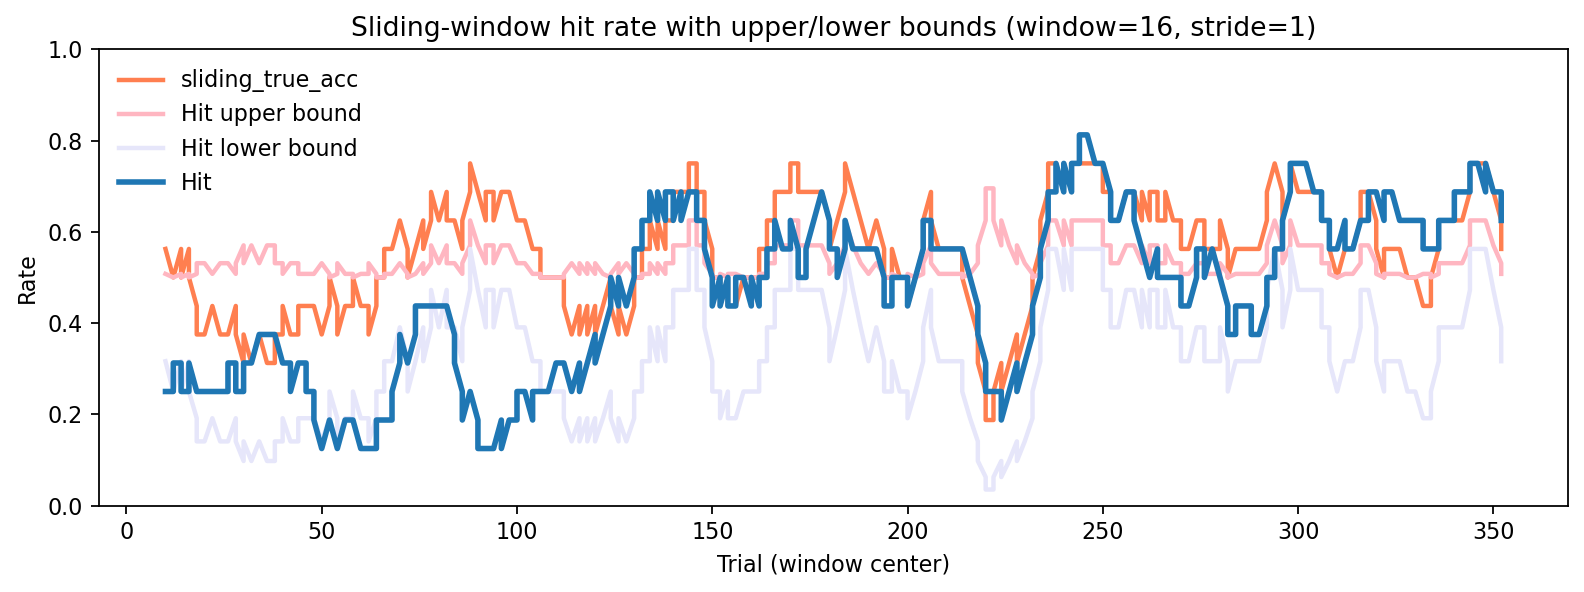

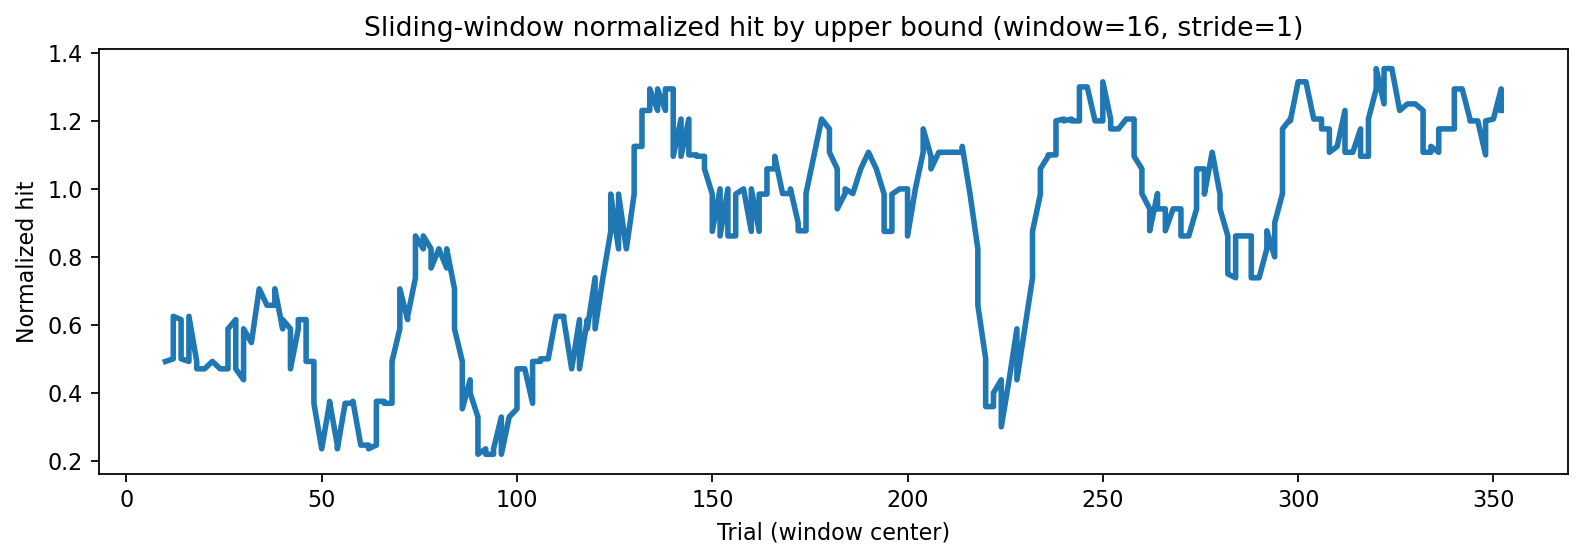

In [23]:
# Cell 1: hit 序列 + 滑窗平均曲线（window=16）
# 新增：
# 1) 添加 hit 上界 / 下界
# 2) 绘制按 hit 上界标准化后的 hit 曲线

import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(processed_path)
rating = df['rating']
choice = df['choice']
probs = prediction[333]['pred_probs']
pred_choice = prediction[333]['pred_choice']
true_acc = prediction[333]['true_acc']   # 逐 trial 的 true_acc（0/1）

rating_np = np.asarray(rating)
choice_np = np.asarray(choice)
pred_np = np.asarray(pred_choice)
probs_np = np.asarray(probs, dtype=float)
true_acc_np = np.asarray(true_acc, dtype=float)

assert len(choice_np) == len(pred_np) == probs_np.shape[0] == len(true_acc_np), \
    f"Length mismatch: choice={len(choice_np)}, pred_choice={len(pred_np)}, probs={probs_np.shape}, true_acc={len(true_acc_np)}"
assert probs_np.shape[1] == 4, f"probs should be (n_trials, 4), got {probs_np.shape}"

# 去掉第1个 trial
choice_np    = choice_np[1:]
pred_np      = pred_np[1:]
rating_np    = rating_np[1:]
probs_np     = probs_np[1:, :]
true_acc_np  = true_acc_np[1:]

trial_id = np.arange(2, 2 + len(choice_np))

valid = np.isfinite(rating_np)
valid &= np.isin(choice_np, [1, 2, 3, 4])
valid &= np.isin(pred_np, [1, 2, 3, 4])
valid &= np.all(np.isfinite(probs_np), axis=1)
valid &= np.isfinite(true_acc_np)
valid &= np.isin(true_acc_np, [0, 1])

choice_c    = choice_np[valid].astype(int)
pred_c      = pred_np[valid].astype(int)
rating_c    = rating_np[valid].astype(float)
probs_c     = probs_np[valid]
true_acc_c  = true_acc_np[valid].astype(float)
trial_c     = trial_id[valid]

print("✅ After cleaning:")
print("n_trials:", len(choice_c))
print("choice unique:", np.unique(choice_c))
print("pred_choice unique:", np.unique(pred_c))
print("rating unique:", np.unique(rating_c))
print("true_acc unique:", np.unique(true_acc_c))

# 1) hit 序列：相同=1，不同=0 
hit = (choice_c == pred_c).astype(float)

# ====== 滑窗平均 ======
def moving_average(x, window=16, stride=1, center=True):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < window:
        raise ValueError(f"n={n} < window={window}")
    starts = np.arange(0, n - window + 1, stride)
    avgs = np.array([x[s:s+window].mean() for s in starts])
    pos = starts + (window - 1) / 2 if center else starts + (window - 1)
    return pos, avgs

window = 16
stride = 1

# hit 的滑窗平均
xpos, hit_ma = moving_average(hit, window=window, stride=stride, center=True)

# true_acc 的滑窗平均 -> sliding_true_acc
_, sliding_true_acc = moving_average(true_acc_c, window=window, stride=stride, center=True)

# 映射到原始 trial 编号（窗口中心）
center_trial = trial_c[np.round(xpos).astype(int)]

# ====== 2) 计算 hit 上界 / 下界 ======
hit_upper = sliding_true_acc**2 + (1 - sliding_true_acc)**2
hit_lower = sliding_true_acc**2

# ====== 3) 画图 ======
plt.figure(figsize=(10, 3.8), dpi=160)
plt.plot(center_trial, sliding_true_acc, linewidth=2, linestyle='-', label='sliding_true_acc',color = 'coral')
plt.plot(center_trial, hit_upper, linewidth=2, linestyle='-', label='Hit upper bound', color = 'lightpink')
plt.plot(center_trial, hit_lower, linewidth=2, linestyle='-', label='Hit lower bound', color = 'lavender')
plt.plot(center_trial, hit_ma, linewidth=2.5, label='Hit')

plt.ylim(0, 1)
plt.xlabel("Trial (window center)")
plt.ylabel("Rate")
plt.title(f"Sliding-window hit rate with upper/lower bounds (window={window}, stride={stride})")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# ====== 4) 按 hit 上界标准化 ======
# 为避免极端情况下分母为0，做一个很小的保护
eps = 1e-12
hit_norm = hit_ma / np.maximum(hit_upper, eps)

plt.figure(figsize=(10, 3.6), dpi=160)
plt.plot(center_trial, hit_norm, linewidth=2.5)
plt.xlabel("Trial (window center)")
plt.ylabel("Normalized hit")
plt.title(f"Sliding-window normalized hit by upper bound (window={window}, stride={stride})")
plt.tight_layout()
plt.show()

## Cell 2: 在 all / hit / not hit 三种条件下评估 7 个 conf 指标

Condition: all
n_trials: 359 / 359

Results for condition = all (rounded to 4 decimals):


,condition,spearman_r,spearman_p,kendall_tau,kendall_p,c_index,ordinal_nll_cv_mean,rating_levels_used,n_trials
metric,,,,,,,,,
p_star,all,0.2145,0.0000,0.1617,0.0001,0.5975,1.2922,"[1, 2, 3, 4, 5]",359
composite,all,0.2083,0.0001,0.1573,0.0001,0.5948,1.2982,"[1, 2, 3, 4, 5]",359
log_margin,all,0.1994,0.0001,0.1500,0.0002,0.5904,1.3002,"[1, 2, 3, 4, 5]",359
margin,all,0.1937,0.0002,0.1458,0.0003,0.5879,1.2971,"[1, 2, 3, 4, 5]",359
entropy_conf,all,0.1391,0.0083,0.1035,0.0099,0.5624,1.3069,"[1, 2, 3, 4, 5]",359
top1,all,0.1336,0.0113,0.0992,0.0134,0.5598,1.3077,"[1, 2, 3, 4, 5]",359
top1_margin,all,0.1104,0.0366,0.0819,0.0412,0.5494,1.3092,"[1, 2, 3, 4, 5]",359


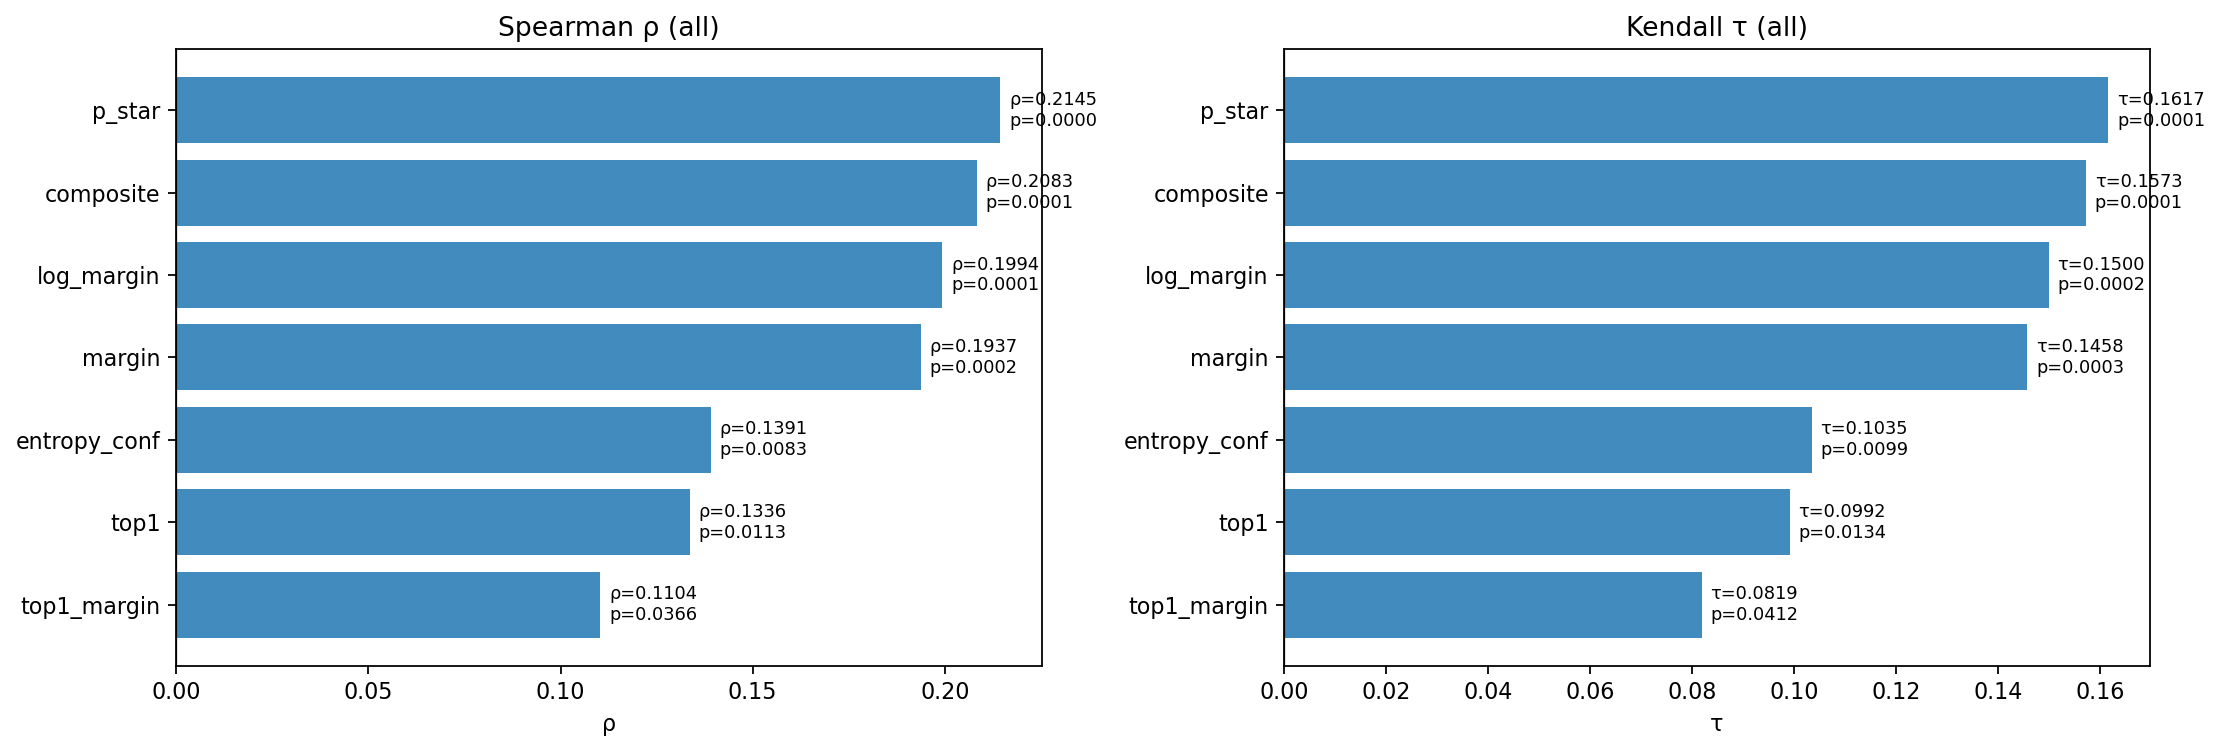

Condition: hit
n_trials: 166 / 359

Results for condition = hit (rounded to 4 decimals):


,condition,spearman_r,spearman_p,kendall_tau,kendall_p,c_index,ordinal_nll_cv_mean,rating_levels_used,n_trials
metric,,,,,,,,,
p_star,hit,0.1181,0.1296,0.0863,0.1395,0.5504,1.4299,"[1, 2, 3, 4, 5]",166
top1,hit,0.1181,0.1296,0.0863,0.1395,0.5504,1.4299,"[1, 2, 3, 4, 5]",166
composite,hit,0.1139,0.1439,0.0825,0.1576,0.5482,1.4379,"[1, 2, 3, 4, 5]",166
log_margin,hit,0.1131,0.1469,0.0813,0.1637,0.5475,1.4391,"[1, 2, 3, 4, 5]",166
margin,hit,0.1120,0.1509,0.0801,0.1700,0.5468,1.4305,"[1, 2, 3, 4, 5]",166
top1_margin,hit,0.1120,0.1509,0.0801,0.1700,0.5468,1.4305,"[1, 2, 3, 4, 5]",166
entropy_conf,hit,0.1036,0.1842,0.0757,0.1949,0.5442,1.4330,"[1, 2, 3, 4, 5]",166


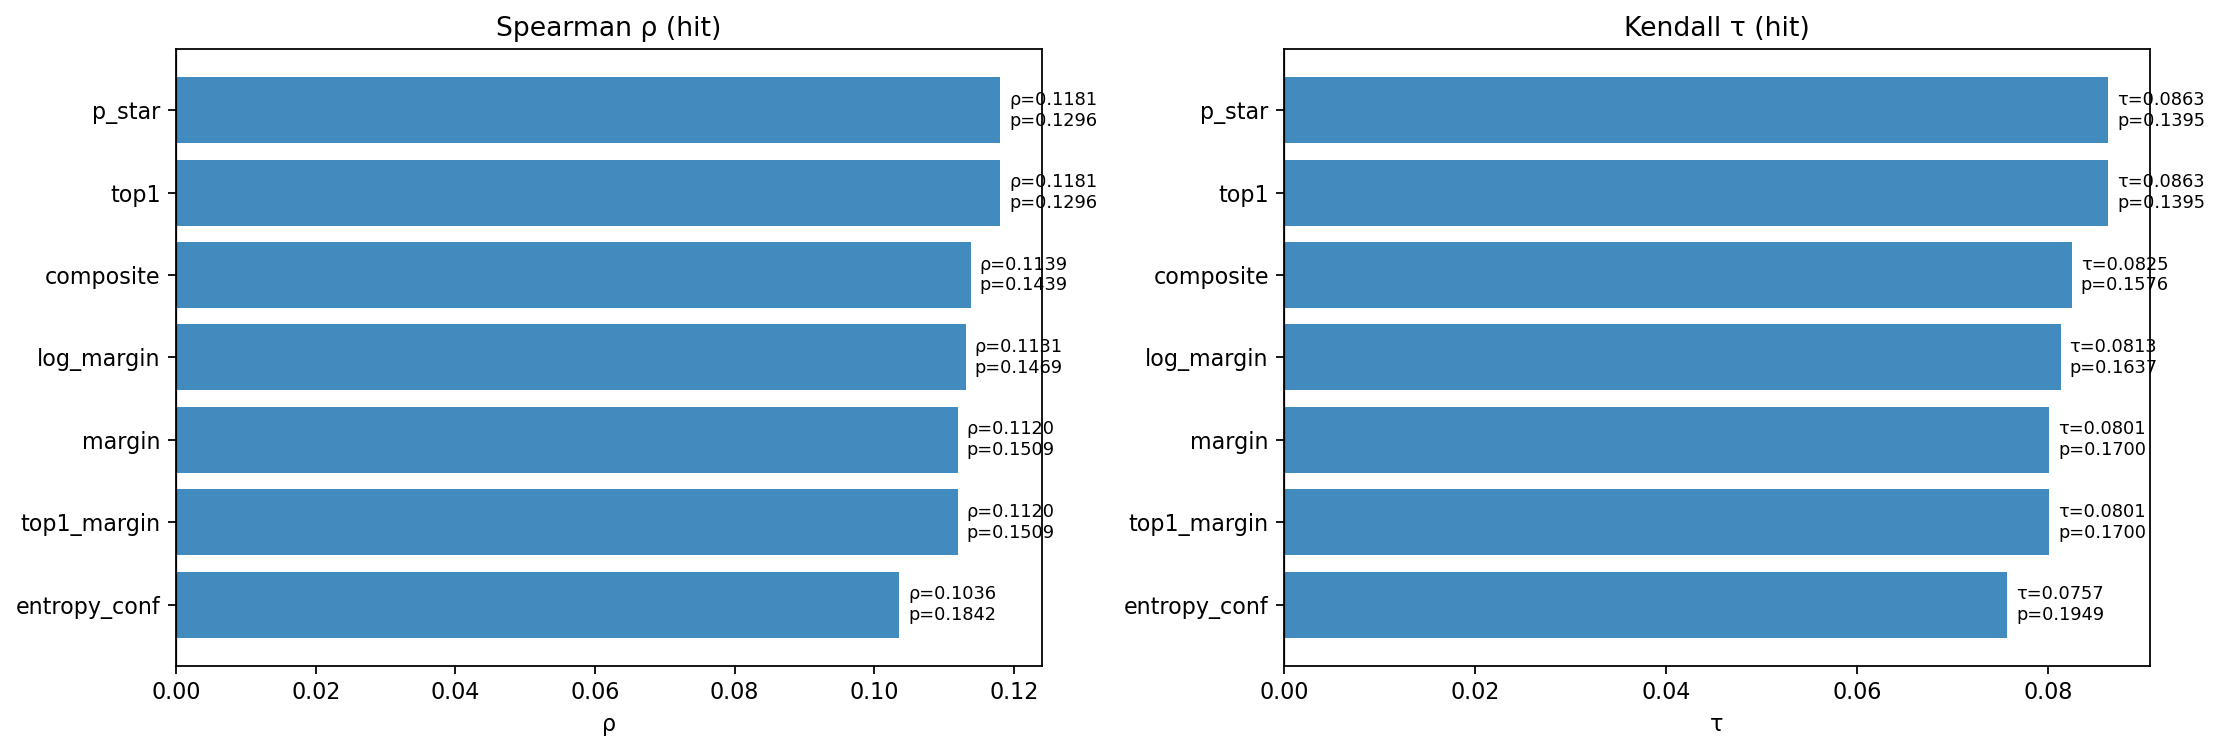

Condition: not_hit
n_trials: 193 / 359

Results for condition = not_hit (rounded to 4 decimals):


,condition,spearman_r,spearman_p,kendall_tau,kendall_p,c_index,ordinal_nll_cv_mean,rating_levels_used,n_trials
metric,,,,,,,,,
p_star,not_hit,0.1065,0.1406,0.0816,0.1433,0.5510,1.1916,"[1, 2, 3, 4, 5]",193
composite,not_hit,0.0901,0.2126,0.0700,0.2093,0.5437,1.1981,"[1, 2, 3, 4, 5]",193
log_margin,not_hit,0.0676,0.3501,0.0505,0.3654,0.5315,1.1992,"[1, 2, 3, 4, 5]",193
margin,not_hit,0.0476,0.5112,0.0365,0.5133,0.5228,1.2015,"[1, 2, 3, 4, 5]",193
entropy_conf,not_hit,0.0319,0.6599,0.0238,0.6697,0.5149,1.1962,"[1, 2, 3, 4, 5]",193
top1,not_hit,0.0150,0.8354,0.0102,0.8552,0.5064,1.2013,"[1, 2, 3, 4, 5]",193
top1_margin,not_hit,-0.0241,0.7395,-0.0177,0.7506,0.4889,1.2047,"[1, 2, 3, 4, 5]",193


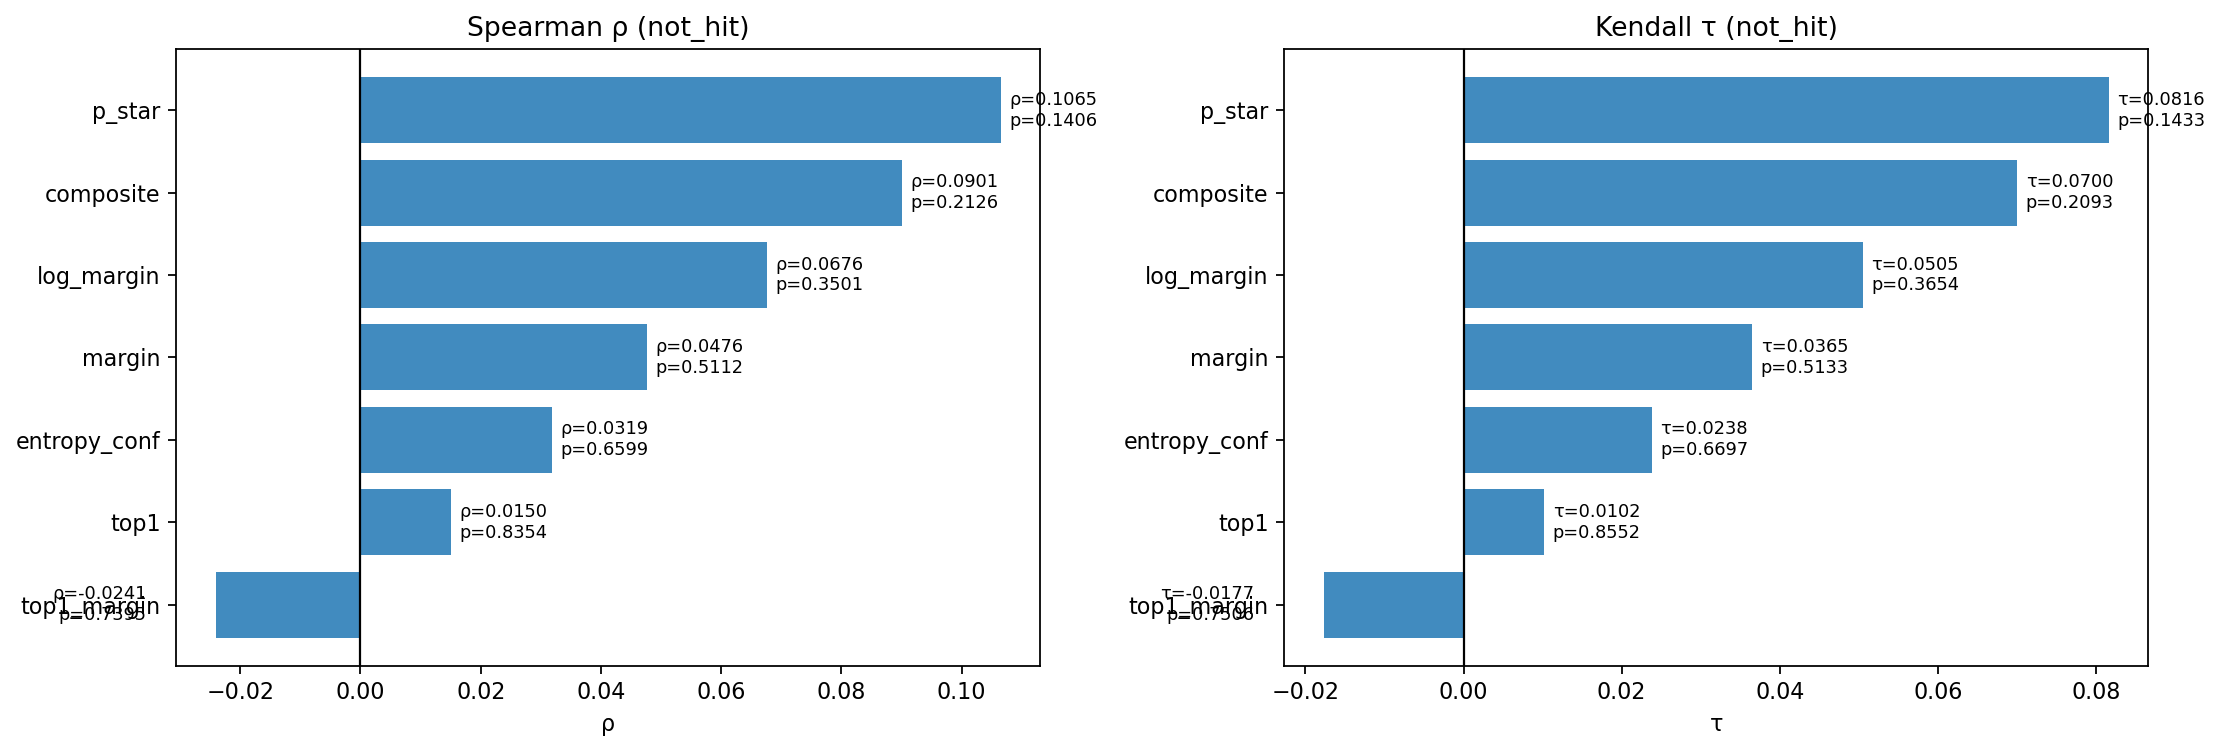

Combined summary table (all / hit / not_hit):


,condition,metric,spearman_r,spearman_p,kendall_tau,kendall_p,c_index,ordinal_nll_cv_mean,n_trials,rating_levels_used
0,all,p_star,0.2145,0.0000,0.1617,0.0001,0.5975,1.2922,359,"[1, 2, 3, 4, 5]"
1,all,composite,0.2083,0.0001,0.1573,0.0001,0.5948,1.2982,359,"[1, 2, 3, 4, 5]"
2,all,log_margin,0.1994,0.0001,0.1500,0.0002,0.5904,1.3002,359,"[1, 2, 3, 4, 5]"
3,all,margin,0.1937,0.0002,0.1458,0.0003,0.5879,1.2971,359,"[1, 2, 3, 4, 5]"
4,all,entropy_conf,0.1391,0.0083,0.1035,0.0099,0.5624,1.3069,359,"[1, 2, 3, 4, 5]"
5,all,top1,0.1336,0.0113,0.0992,0.0134,0.5598,1.3077,359,"[1, 2, 3, 4, 5]"
6,all,top1_margin,0.1104,0.0366,0.0819,0.0412,0.5494,1.3092,359,"[1, 2, 3, 4, 5]"
7,hit,p_star,0.1181,0.1296,0.0863,0.1395,0.5504,1.4299,166,"[1, 2, 3, 4, 5]"
8,hit,top1,0.1181,0.1296,0.0863,0.1395,0.5504,1.4299,166,"[1, 2, 3, 4, 5]"
9,hit,composite,0.1139,0.1439,0.0825,0.1576,0.5482,1.4379,166,"[1, 2, 3, 4, 5]"


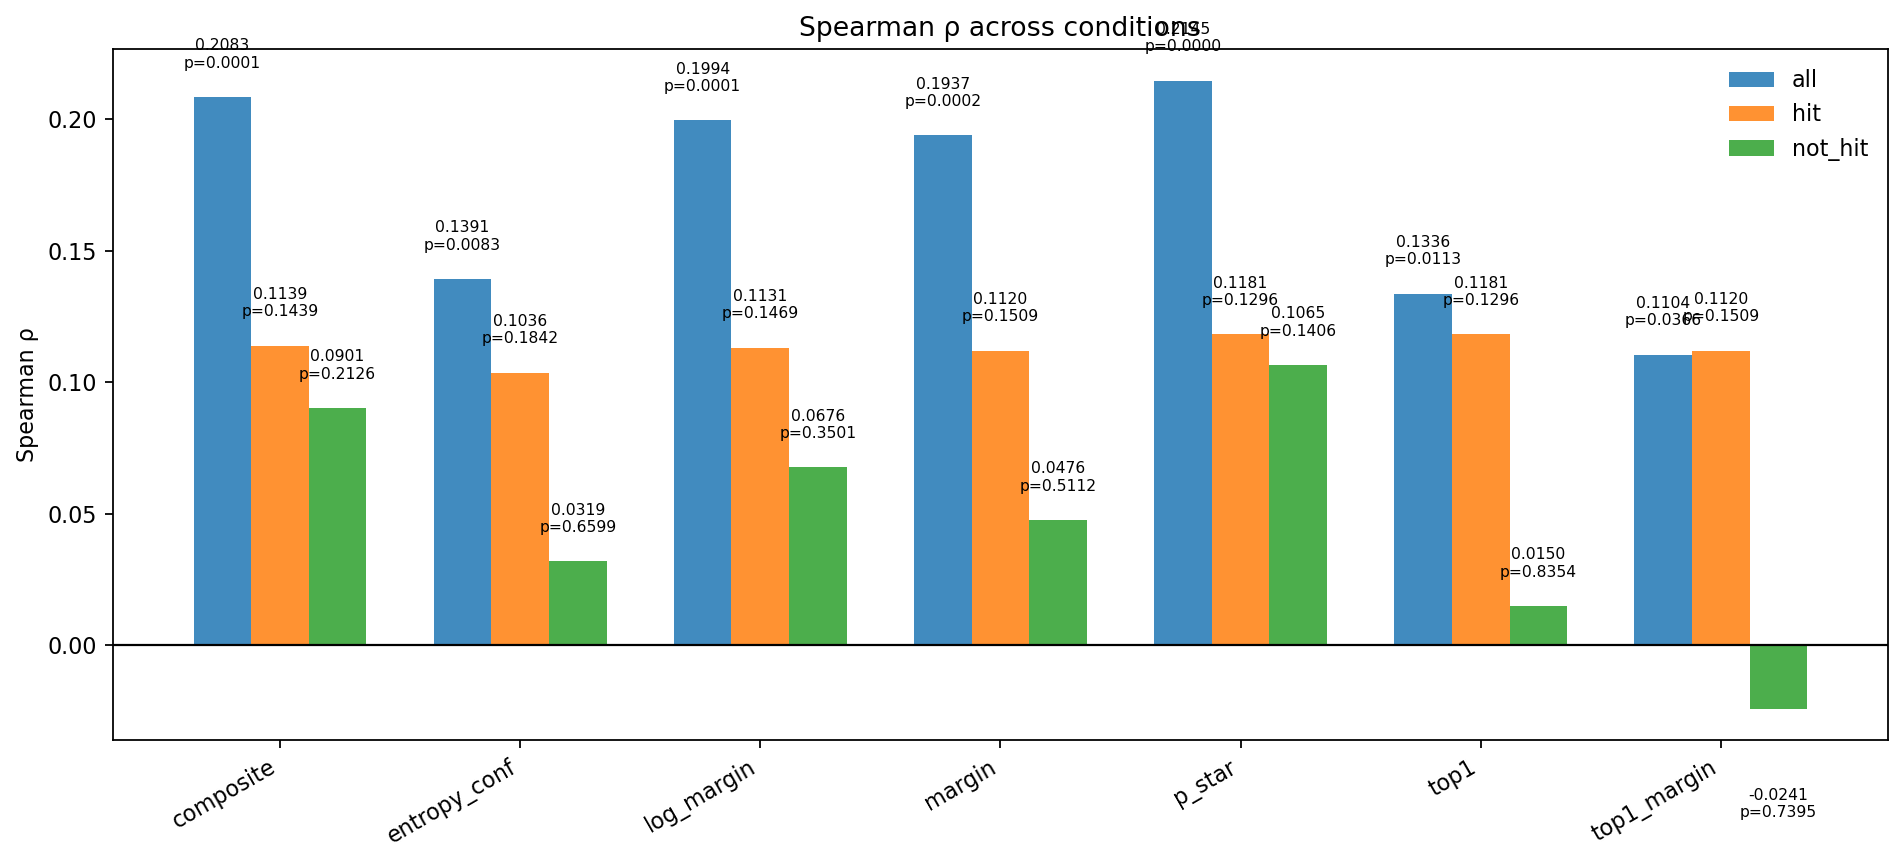

In [24]:
# Cell 2: 在 all / hit / not hit 三种条件下评估 7 个 conf 指标
# 输出相关系数和 p-value 表格，并进行可视化（四位小数，图中标注数值）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau
from scipy.special import expit
from scipy.optimize import minimize

# 0) 通用函数

def normalize_probs(probs, eps=1e-12):
    probs = np.asarray(probs, dtype=float)
    row_sum = np.clip(probs.sum(axis=1, keepdims=True), eps, None)
    return probs / row_sum

def build_conf_dict(choice, probs, alpha=0.5, eps=1e-12):
    """
    根据 choice 和 probs 计算 7 个 confidence 指标
    choice: 1~4
    probs : (n_trials, 4)
    """
    choice = np.asarray(choice, dtype=int)
    probs = normalize_probs(probs, eps=eps)

    choice0 = choice - 1  # 1-4 -> 0-3
    n = len(choice0)

    p_star = probs[np.arange(n), choice0]

    probs_other = probs.copy()
    probs_other[np.arange(n), choice0] = -np.inf
    p2 = np.clip(np.max(probs_other, axis=1), eps, 1.0)

    margin = p_star - p2
    log_margin = np.log(np.clip(p_star, eps, 1.0)) - np.log(p2)

    top1 = np.max(probs, axis=1)
    sorted_probs = np.sort(probs, axis=1)
    top1_margin = sorted_probs[:, -1] - sorted_probs[:, -2]

    p_clip = np.clip(probs, eps, 1.0)
    H = -np.sum(p_clip * np.log(p_clip), axis=1)              # nats
    entropy_conf = 1.0 - H / np.log(probs.shape[1])           # 归一化到[0,1]

    composite = alpha * log_margin + (1 - alpha) * entropy_conf

    conf_dict = {
        "p_star": p_star,
        "log_margin": log_margin,
        "margin": margin,
        "composite": composite,
        "top1": top1,
        "top1_margin": top1_margin,
        "entropy_conf": entropy_conf,
    }
    return conf_dict

def c_index(y, x):
    """
    C-index：随机抽两题，conf 排序与 rating 排序一致的比例（0.5=随机）
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    n = len(y)
    ii, jj = np.triu_indices(n, k=1)
    dy = y[ii] - y[jj]
    dx = x[ii] - x[jj]
    valid = dy != 0
    dy, dx = dy[valid], dx[valid]
    if dy.size == 0:
        return np.nan
    concord = np.sum((dy > 0) & (dx > 0)) + np.sum((dy < 0) & (dx < 0))
    discord = np.sum((dy > 0) & (dx < 0)) + np.sum((dy < 0) & (dx > 0))
    ties = dy.size - concord - discord
    return float((concord + 0.5 * ties) / dy.size)

def _pack_thresholds(theta1, deltas):
    thetas = [theta1]
    cur = theta1
    for d in deltas:
        cur = cur + np.exp(d)   # 保证阈值严格递增
        thetas.append(cur)
    return np.array(thetas)

def ordered_logit_nll(params, x, y, n_classes, eps=1e-12):
    a = params[0]
    theta1 = params[1]
    deltas = params[2:]
    thetas = _pack_thresholds(theta1, deltas)  # length = K-1

    z = a * x
    cdf = expit(thetas[None, :] - z[:, None])  # (n, K-1)

    n = len(x)
    p = np.empty((n, n_classes), dtype=float)
    p[:, 0] = cdf[:, 0]
    for k in range(1, n_classes - 1):
        p[:, k] = cdf[:, k] - cdf[:, k - 1]
    p[:, -1] = 1.0 - cdf[:, -1]
    p = np.clip(p, eps, 1.0)

    idx = y.astype(int) - 1
    return -np.mean(np.log(p[np.arange(n), idx]))

def fit_ordered_logit(x, y, n_classes):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=int)

    qs = np.quantile(x, np.linspace(1/n_classes, (n_classes-1)/n_classes, n_classes-1))
    a0 = 1.0
    thetas0 = qs * a0
    theta1_0 = thetas0[0]
    gaps = np.diff(thetas0)
    gaps = np.clip(gaps, 1e-2, None)
    deltas0 = np.log(gaps)
    p0 = np.concatenate([[a0, theta1_0], deltas0])

    res = minimize(ordered_logit_nll, p0, args=(x, y, n_classes), method="L-BFGS-B")
    return res.x

def cv_ordinal_nll(conf, rating, n_folds=5, seed=0):
    conf = np.asarray(conf, dtype=float)
    rating = np.asarray(rating, dtype=int)

    levels = np.sort(np.unique(rating))
    level_map = {lv: i + 1 for i, lv in enumerate(levels)}
    y = np.array([level_map[r] for r in rating], dtype=int)
    K = len(levels)

    if K < 2:
        return np.nan, [], levels

    n = len(y)
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    folds = np.array_split(idx, min(n_folds, n))

    fold_nlls = []
    for f in range(len(folds)):
        te = folds[f]
        tr = np.concatenate([folds[j] for j in range(len(folds)) if j != f])

        params = fit_ordered_logit(conf[tr], y[tr], n_classes=K)
        nll = ordered_logit_nll(params, conf[te], y[te], n_classes=K)
        fold_nlls.append(float(nll))

    return float(np.mean(fold_nlls)), fold_nlls, levels

def evaluate_conf_metrics(rating, choice, probs, cond_name="all", alpha=0.5, n_folds=5, seed=0):
    """
    在某个条件子集上评估全部 conf 指标
    """
    rating = np.asarray(rating, dtype=float)
    choice = np.asarray(choice, dtype=int)
    probs = np.asarray(probs, dtype=float)

    conf_dict = build_conf_dict(choice, probs, alpha=alpha)

    rows = []
    for name, conf in conf_dict.items():
        conf = np.asarray(conf, dtype=float)

        sp = spearmanr(rating, conf)
        kd = kendalltau(rating, conf)
        ci = c_index(rating, conf)
        nll_mean, nll_folds, used_levels = cv_ordinal_nll(conf, rating, n_folds=n_folds, seed=seed)

        rows.append({
            "condition": cond_name,
            "metric": name,
            "spearman_r": float(sp.correlation),
            "spearman_p": float(sp.pvalue),
            "kendall_tau": float(kd.correlation),
            "kendall_p": float(kd.pvalue),
            "c_index": float(ci),
            "ordinal_nll_cv_mean": float(nll_mean) if np.isfinite(nll_mean) else np.nan,
            "ordinal_nll_cv_folds": nll_folds,
            "rating_levels_used": used_levels.tolist(),
            "n_trials": int(len(rating)),
        })

    res_df = pd.DataFrame(rows).set_index("metric")
    return res_df, conf_dict

def format_result_table(res_df):
    """
    保留四位小数，用于展示
    """
    show_cols = ["spearman_r", "spearman_p", "kendall_tau", "kendall_p", "c_index", "ordinal_nll_cv_mean"]
    res_show = res_df.copy()
    res_show[show_cols] = res_show[show_cols].round(4)
    res_show = res_show.sort_values(["spearman_r", "ordinal_nll_cv_mean"], ascending=[False, True])
    return res_show

def plot_corr_results(res_show, cond_name):
    """
    可视化：
    左图 Spearman rho，标注 rho 和 p
    右图 Kendall tau，标注 tau 和 p
    """
    plot_df = res_show.copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), dpi=160)

    # -----------------------------
    # 左：Spearman rho
    # -----------------------------
    axes[0].barh(plot_df.index, plot_df["spearman_r"], alpha=0.85)
    axes[0].axvline(0, color="k", linewidth=1)
    axes[0].set_title(f"Spearman ρ ({cond_name})")
    axes[0].set_xlabel("ρ")
    axes[0].invert_yaxis()

    x_range0 = axes[0].get_xlim()[1] - axes[0].get_xlim()[0]
    offset0 = x_range0 * 0.01

    for i, m in enumerate(plot_df.index):
        rho = plot_df.loc[m, "spearman_r"]
        p   = plot_df.loc[m, "spearman_p"]
        axes[0].text(
            rho + (offset0 if rho >= 0 else -offset0 * 8),
            i,
            f"ρ={rho:.4f}\np={p:.4f}",
            va="center",
            ha="left" if rho >= 0 else "right",
            fontsize=8
        )

    # -----------------------------
    # 右：Kendall tau
    # -----------------------------
    axes[1].barh(plot_df.index, plot_df["kendall_tau"], alpha=0.85)
    axes[1].axvline(0, color="k", linewidth=1)
    axes[1].set_title(f"Kendall τ ({cond_name})")
    axes[1].set_xlabel("τ")
    axes[1].invert_yaxis()

    x_range1 = axes[1].get_xlim()[1] - axes[1].get_xlim()[0]
    offset1 = x_range1 * 0.01

    for i, m in enumerate(plot_df.index):
        tau = plot_df.loc[m, "kendall_tau"]
        p   = plot_df.loc[m, "kendall_p"]
        axes[1].text(
            tau + (offset1 if tau >= 0 else -offset1 * 8),
            i,
            f"τ={tau:.4f}\np={p:.4f}",
            va="center",
            ha="left" if tau >= 0 else "right",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

def subset_by_condition(rating_c, choice_c, probs_c, hit, cond_name):
    """
    根据条件选择 trial 子集
    """
    if cond_name == "all":
        mask = np.ones(len(hit), dtype=bool)
    elif cond_name == "hit":
        mask = (hit == 1)
    elif cond_name == "not_hit":
        mask = (hit == 0)
    else:
        raise ValueError(f"Unknown condition: {cond_name}")

    rating_sub = np.asarray(rating_c)[mask]
    choice_sub = np.asarray(choice_c)[mask]
    probs_sub  = np.asarray(probs_c)[mask]
    return rating_sub, choice_sub, probs_sub, mask


# 1) 准备条件

conditions = ["all", "hit", "not_hit"]

all_results = {}
all_results_show = {}
summary_rows = []

for cond in conditions:
    rating_sub, choice_sub, probs_sub, mask_sub = subset_by_condition(
        rating_c=rating_c,
        choice_c=choice_c,
        probs_c=probs_c,
        hit=hit,
        cond_name=cond
    )

    print("=" * 70)
    print(f"Condition: {cond}")
    print(f"n_trials: {len(rating_sub)} / {len(rating_c)}")

    res_df, conf_dict = evaluate_conf_metrics(
        rating=rating_sub,
        choice=choice_sub,
        probs=probs_sub,
        cond_name=cond,
        alpha=0.5,
        n_folds=5,
        seed=0
    )

    res_show = format_result_table(res_df)

    all_results[cond] = res_df
    all_results_show[cond] = res_show

    print(f"\nResults for condition = {cond} (rounded to 4 decimals):")
    display(res_show[[
        "condition", "spearman_r", "spearman_p",
        "kendall_tau", "kendall_p",
        "c_index", "ordinal_nll_cv_mean",
        "rating_levels_used", "n_trials"
    ]])

    plot_corr_results(res_show, cond_name=cond)

    # 汇总行
    tmp = res_show.reset_index().copy()
    summary_rows.append(tmp)


# 2) 合并成总表，便于横向比较
summary_df = pd.concat(summary_rows, axis=0, ignore_index=True)

summary_show = summary_df.copy()
round_cols = ["spearman_r", "spearman_p", "kendall_tau", "kendall_p", "c_index", "ordinal_nll_cv_mean"]
summary_show[round_cols] = summary_show[round_cols].round(4)

summary_show = summary_show[[
    "condition", "metric",
    "spearman_r", "spearman_p",
    "kendall_tau", "kendall_p",
    "c_index", "ordinal_nll_cv_mean",
    "n_trials", "rating_levels_used"
]]

print("=" * 70)
print("Combined summary table (all / hit / not_hit):")
display(summary_show.sort_values(["condition", "spearman_r"], ascending=[True, False]))

# 3) 额外做一个总览可视化：不同条件下 Spearman rho 对比

pivot_rho = summary_show.pivot(index="metric", columns="condition", values="spearman_r")
pivot_p   = summary_show.pivot(index="metric", columns="condition", values="spearman_p")

cond_order = ["all", "hit", "not_hit"]
pivot_rho = pivot_rho[[c for c in cond_order if c in pivot_rho.columns]]
pivot_p   = pivot_p[[c for c in cond_order if c in pivot_p.columns]]

x = np.arange(len(pivot_rho.index))
width = 0.24

fig, ax = plt.subplots(figsize=(12, 5.5), dpi=160)

for i, cond in enumerate(pivot_rho.columns):
    vals = pivot_rho[cond].values
    bars = ax.bar(x + (i - 1) * width, vals, width=width, label=cond, alpha=0.85)

    for j, b in enumerate(bars):
        v = vals[j]
        p = pivot_p.loc[pivot_rho.index[j], cond]
        ax.text(
            b.get_x() + b.get_width() / 2,
            v + (0.01 if v >= 0 else -0.03),
            f"{v:.4f}\np={p:.4f}",
            ha="center",
            va="bottom" if v >= 0 else "top",
            fontsize=7
        )

ax.axhline(0, color="k", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(pivot_rho.index, rotation=30, ha="right")
ax.set_ylabel("Spearman ρ")
ax.set_title("Spearman ρ across conditions")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

All cleaned trials: 359
All-trials evaluation (rounded to 4 decimals):


,spearman_r,spearman_p,kendall_tau,kendall_p,c_index,ordinal_nll_cv_mean,rating_levels_used,n_trials
metric,,,,,,,,
p_star,0.2145,0.0000,0.1617,0.0001,0.5975,1.2922,"[1, 2, 3, 4, 5]",359
margin,0.1937,0.0002,0.1458,0.0003,0.5879,1.2971,"[1, 2, 3, 4, 5]",359
composite,0.2083,0.0001,0.1573,0.0001,0.5948,1.2982,"[1, 2, 3, 4, 5]",359
log_margin,0.1994,0.0001,0.1500,0.0002,0.5904,1.3002,"[1, 2, 3, 4, 5]",359
entropy_conf,0.1391,0.0083,0.1035,0.0099,0.5624,1.3069,"[1, 2, 3, 4, 5]",359
top1,0.1336,0.0113,0.0992,0.0134,0.5598,1.3077,"[1, 2, 3, 4, 5]",359
top1_margin,0.1104,0.0366,0.0819,0.0412,0.5494,1.3092,"[1, 2, 3, 4, 5]",359


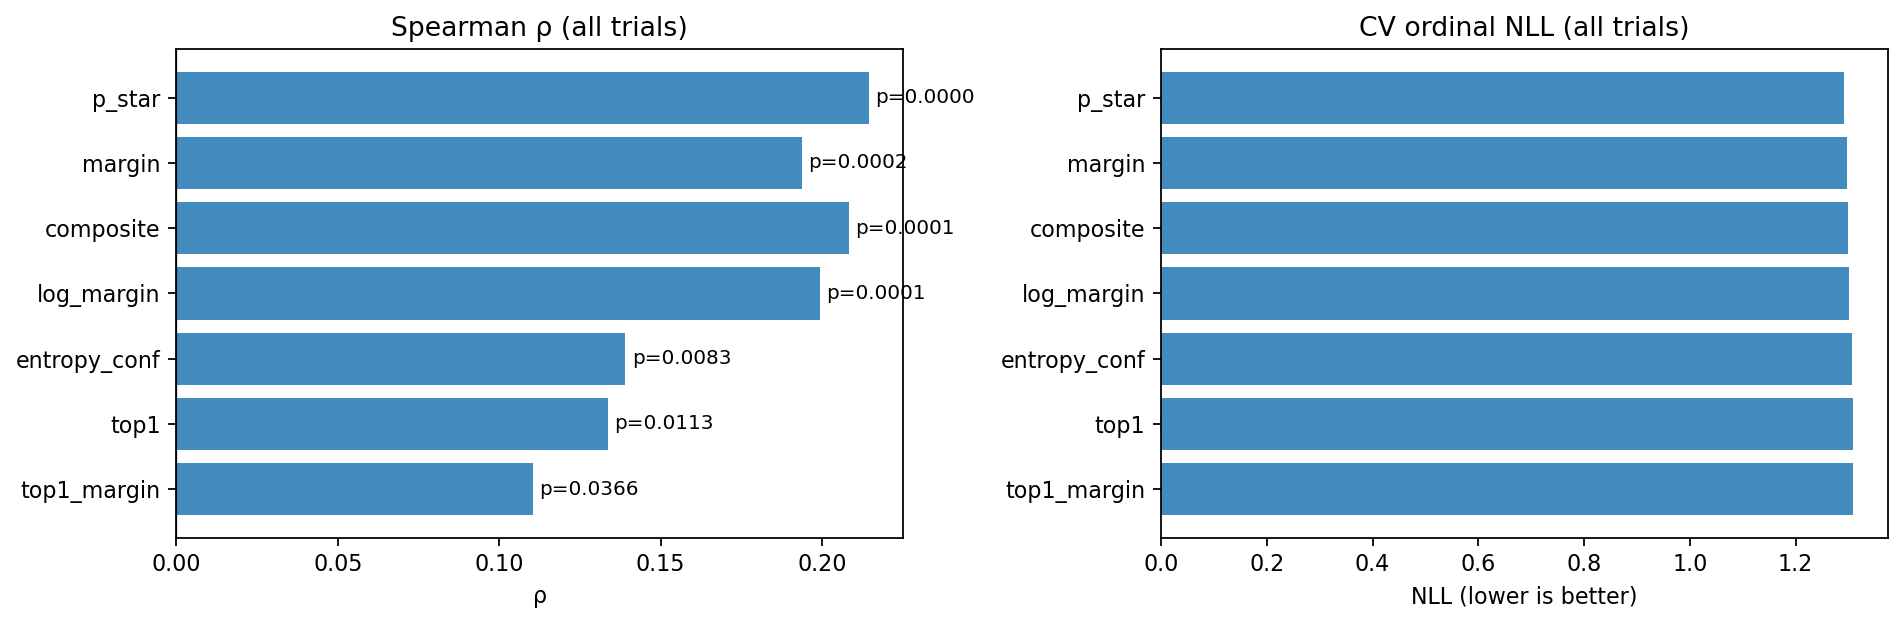

In [25]:
# Cell 3: 全试次评估 7 个 conf 指标（四位小数 + 可视化）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau
from scipy.special import expit
from scipy.optimize import minimize

# 1) 全试次子集（clean 后的全部 trial）
rating_a = np.asarray(rating_c, dtype=float)
choice_a = np.asarray(choice_c, dtype=int)
probs_a  = np.asarray(probs_c, dtype=float)

print(f"All cleaned trials: {len(rating_a)}")

# 2) 概率归一化（避免行和不为1）
eps = 1e-12
row_sum = np.clip(probs_a.sum(axis=1, keepdims=True), eps, None)
probs_a = probs_a / row_sum

# 3) 计算 7 个 conf 指标
choice0 = choice_a - 1  # 1-4 -> 0-3

p_star = probs_a[np.arange(len(choice0)), choice0]

probs_other = probs_a.copy()
probs_other[np.arange(len(choice0)), choice0] = -np.inf
p2 = np.clip(np.max(probs_other, axis=1), eps, 1.0)

margin = p_star - p2
log_margin = np.log(np.clip(p_star, eps, 1.0)) - np.log(p2)

top1 = np.max(probs_a, axis=1)
sorted_probs = np.sort(probs_a, axis=1)
top1_margin = sorted_probs[:, -1] - sorted_probs[:, -2]

p_clip = np.clip(probs_a, eps, 1.0)
H = -np.sum(p_clip * np.log(p_clip), axis=1)          # nats
entropy_conf = 1.0 - H / np.log(probs_a.shape[1])     # 归一化到[0,1]

alpha = 0.5
composite = alpha * log_margin + (1 - alpha) * entropy_conf

conf_dict = {
    "p_star": p_star,
    "log_margin": log_margin,
    "margin": margin,
    "composite": composite,
    "top1": top1,
    "top1_margin": top1_margin,
    "entropy_conf": entropy_conf,
}

# 4) C-index：成对排序一致率（0.5=随机）
def c_index(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    n = len(y)
    ii, jj = np.triu_indices(n, k=1)
    dy = y[ii] - y[jj]
    dx = x[ii] - x[jj]
    valid = dy != 0
    dy, dx = dy[valid], dx[valid]
    if dy.size == 0:
        return np.nan
    concord = np.sum((dy > 0) & (dx > 0)) + np.sum((dy < 0) & (dx < 0))
    discord = np.sum((dy > 0) & (dx < 0)) + np.sum((dy < 0) & (dx > 0))
    ties = dy.size - concord - discord
    return float((concord + 0.5 * ties) / dy.size)

# 5) CV ordinal NLL：交叉验证下拟合评估读出层 ordered-logit
def _pack_thresholds(theta1, deltas):
    thetas = [theta1]
    cur = theta1
    for d in deltas:
        cur = cur + np.exp(d)   # 阈值严格递增
        thetas.append(cur)
    return np.array(thetas)

def ordered_logit_nll(params, x, y, n_classes, eps=1e-12):
    a = params[0]
    theta1 = params[1]
    deltas = params[2:]
    thetas = _pack_thresholds(theta1, deltas)  # length = K-1

    z = a * x
    cdf = expit(thetas[None, :] - z[:, None])  # (n, K-1)

    n = len(x)
    p = np.empty((n, n_classes), dtype=float)
    p[:, 0] = cdf[:, 0]
    for k in range(1, n_classes - 1):
        p[:, k] = cdf[:, k] - cdf[:, k - 1]
    p[:, -1] = 1.0 - cdf[:, -1]
    p = np.clip(p, eps, 1.0)

    idx = y.astype(int) - 1
    return -np.mean(np.log(p[np.arange(n), idx]))

def fit_ordered_logit(x, y, n_classes):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=int)

    qs = np.quantile(x, np.linspace(1/n_classes, (n_classes-1)/n_classes, n_classes-1))
    a0 = 1.0
    thetas0 = qs * a0
    theta1_0 = thetas0[0]
    gaps = np.diff(thetas0)
    gaps = np.clip(gaps, 1e-2, None)
    deltas0 = np.log(gaps)
    p0 = np.concatenate([[a0, theta1_0], deltas0])

    res = minimize(ordered_logit_nll, p0, args=(x, y, n_classes), method="L-BFGS-B")
    return res.x

def cv_ordinal_nll(conf, rating, n_folds=5, seed=0):
    conf = np.asarray(conf, dtype=float)
    rating = np.asarray(rating, dtype=int)

    levels = np.sort(np.unique(rating))
    level_map = {lv: i + 1 for i, lv in enumerate(levels)}
    y = np.array([level_map[r] for r in rating], dtype=int)
    K = len(levels)
    if K < 2:
        return np.nan, [], levels

    n = len(y)
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    folds = np.array_split(idx, min(n_folds, n))

    fold_nlls = []
    for f in range(len(folds)):
        te = folds[f]
        tr = np.concatenate([folds[j] for j in range(len(folds)) if j != f])

        params = fit_ordered_logit(conf[tr], y[tr], n_classes=K)
        nll = ordered_logit_nll(params, conf[te], y[te], n_classes=K)
        fold_nlls.append(float(nll))

    return float(np.mean(fold_nlls)), fold_nlls, levels

# 6) 逐指标评估并汇总
rows = []
for name, conf in conf_dict.items():
    conf = np.asarray(conf, dtype=float)

    sp = spearmanr(rating_a, conf)
    kd = kendalltau(rating_a, conf)
    ci = c_index(rating_a, conf)
    nll_mean, nll_folds, used_levels = cv_ordinal_nll(conf, rating_a, n_folds=5, seed=0)

    rows.append({
        "metric": name,
        "spearman_r": float(sp.correlation),
        "spearman_p": float(sp.pvalue),
        "kendall_tau": float(kd.correlation),
        "kendall_p": float(kd.pvalue),
        "c_index": float(ci),
        "ordinal_nll_cv_mean": float(nll_mean) if np.isfinite(nll_mean) else np.nan,
        "ordinal_nll_cv_folds": nll_folds,
        "rating_levels_used": used_levels.tolist(),
        "n_trials": int(len(rating_a)),
    })

res_df_all = pd.DataFrame(rows).set_index("metric")

# 表格展示：保留四位小数（folds 与 levels 保留原样）
show_cols = ["spearman_r", "spearman_p", "kendall_tau", "kendall_p", "c_index", "ordinal_nll_cv_mean"]
res_show_all = res_df_all.copy()
res_show_all[show_cols] = res_show_all[show_cols].round(4)

# 排序：先看 NLL（越小越好），再看 Spearman（越大越好）
res_show_all = res_show_all.sort_values(["ordinal_nll_cv_mean", "spearman_r"], ascending=[True, False])

print("All-trials evaluation (rounded to 4 decimals):")
display(res_show_all[show_cols + ["rating_levels_used", "n_trials"]])

# 7) 可视化：Spearman ρ（标注p）与 CV ordinal NLL
plot_df = res_show_all.copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=160)

axes[0].barh(plot_df.index, plot_df["spearman_r"], alpha=0.85)
axes[0].axvline(0, color="k", linewidth=1)
axes[0].set_title("Spearman ρ (all trials)")
axes[0].set_xlabel("ρ")
axes[0].invert_yaxis()
for i, m in enumerate(plot_df.index):
    axes[0].text(plot_df.loc[m, "spearman_r"] + 0.002, i,
                 f"p={plot_df.loc[m,'spearman_p']:.4f}",
                 va="center", fontsize=9)

axes[1].barh(plot_df.index, plot_df["ordinal_nll_cv_mean"], alpha=0.85)
axes[1].set_title("CV ordinal NLL (all trials)")
axes[1].set_xlabel("NLL (lower is better)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

✅ Comparison table: all trials vs hit==1 (rounded to 4 decimals)


,all_spearman_r,all_spearman_p,all_kendall_tau,all_kendall_p,all_c_index,all_ordinal_nll_cv_mean,hit_spearman_r,hit_spearman_p,hit_kendall_tau,hit_kendall_p,hit_c_index,hit_ordinal_nll_cv_mean,delta_spearman_r,delta_kendall_tau,delta_c_index,delta_ordinal_nll
metric,,,,,,,,,,,,,,,,
p_star,0.2145,0.0000,0.1617,0.0001,0.5975,1.2922,0.1065,0.1406,0.0816,0.1433,0.5510,1.1916,-0.1080,-0.0801,-0.0465,-0.1006
margin,0.1937,0.0002,0.1458,0.0003,0.5879,1.2971,0.0476,0.5112,0.0365,0.5133,0.5228,1.2015,-0.1461,-0.1094,-0.0652,-0.0956
composite,0.2083,0.0001,0.1573,0.0001,0.5948,1.2982,0.0901,0.2126,0.0700,0.2093,0.5437,1.1981,-0.1182,-0.0873,-0.0511,-0.1001
log_margin,0.1994,0.0001,0.1500,0.0002,0.5904,1.3002,0.0676,0.3501,0.0505,0.3654,0.5315,1.1992,-0.1318,-0.0995,-0.0589,-0.1010
entropy_conf,0.1391,0.0083,0.1035,0.0099,0.5624,1.3069,0.0319,0.6599,0.0238,0.6697,0.5149,1.1962,-0.1073,-0.0797,-0.0475,-0.1107
top1,0.1336,0.0113,0.0992,0.0134,0.5598,1.3077,0.0150,0.8354,0.0102,0.8552,0.5064,1.2013,-0.1185,-0.0890,-0.0534,-0.1063
top1_margin,0.1104,0.0366,0.0819,0.0412,0.5494,1.3092,-0.0241,0.7395,-0.0177,0.7506,0.4889,1.2047,-0.1345,-0.0996,-0.0604,-0.1045


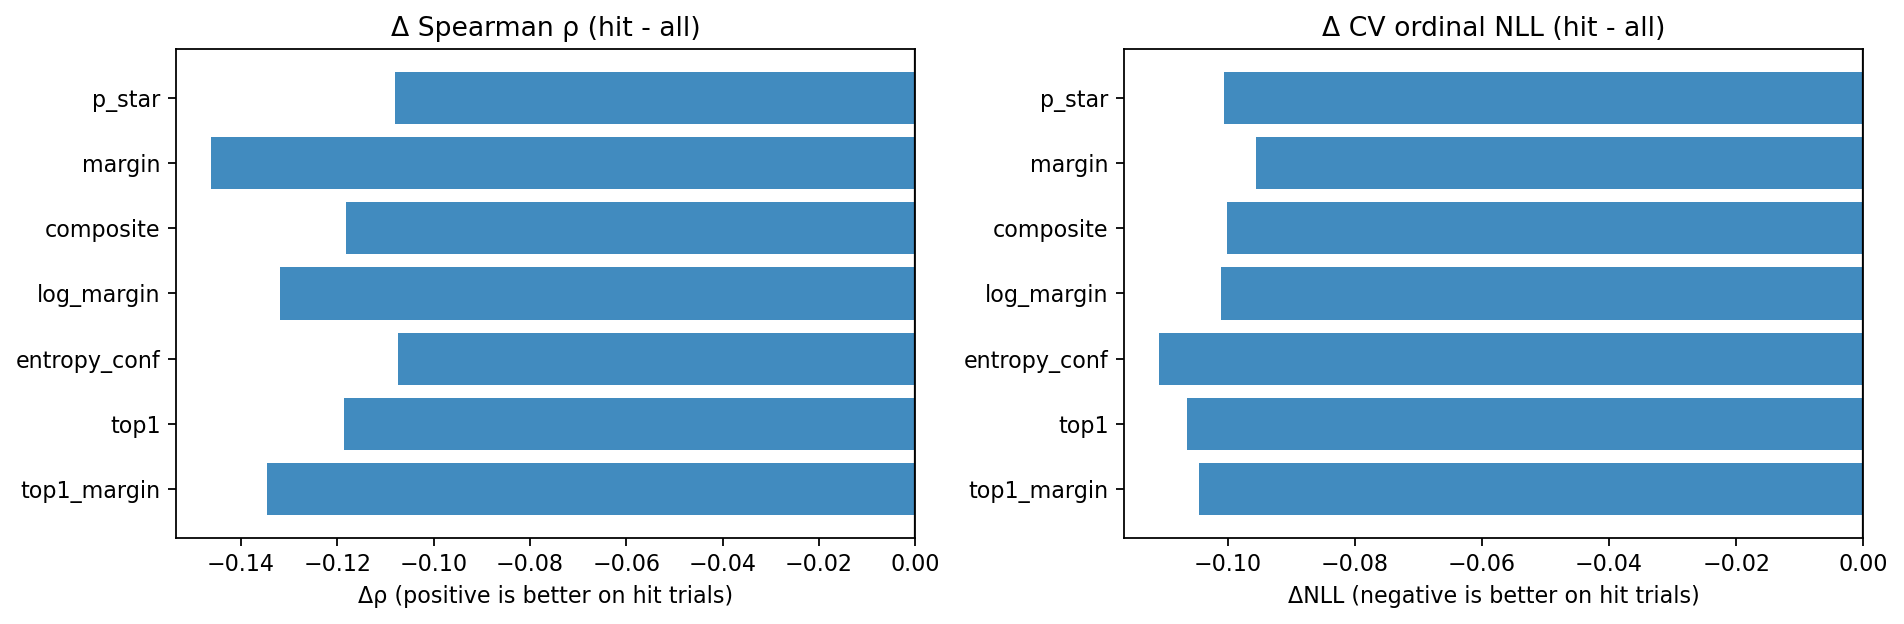

In [26]:
# Cell 4: 对比表（all vs hit==1）+ 差值可视化

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 必要列
cols = ["spearman_r", "spearman_p", "kendall_tau", "kendall_p", "c_index", "ordinal_nll_cv_mean"]

# 只取公共指标（理论上是同一套7个）
common_metrics = sorted(set(res_df_all.index) & set(res_df.index))

all_tab = res_df_all.loc[common_metrics, cols].copy()
hit_tab = res_df.loc[common_metrics, cols].copy()

# 为列名加前缀
all_tab = all_tab.add_prefix("all_")
hit_tab = hit_tab.add_prefix("hit_")

# 合并
cmp = pd.concat([all_tab, hit_tab], axis=1)

# 差值（hit - all）：相关越大越好；NLL 越小越好，所以差值越负越好
cmp["delta_spearman_r"] = cmp["hit_spearman_r"] - cmp["all_spearman_r"]
cmp["delta_kendall_tau"] = cmp["hit_kendall_tau"] - cmp["all_kendall_tau"]
cmp["delta_c_index"] = cmp["hit_c_index"] - cmp["all_c_index"]
cmp["delta_ordinal_nll"] = cmp["hit_ordinal_nll_cv_mean"] - cmp["all_ordinal_nll_cv_mean"]

# 四位小数展示
cmp_show = cmp.round(4)

# 推荐排序：先看全试次的 NLL（越小越好），再看全试次的 Spearman（越大越好）
cmp_show = cmp_show.sort_values(["all_ordinal_nll_cv_mean", "all_spearman_r"], ascending=[True, False])

print("✅ Comparison table: all trials vs hit==1 (rounded to 4 decimals)")
display(cmp_show)

# 可视化差值：Spearman 和 NLL
metrics_order = list(cmp_show.index)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=160)

# 1) Spearman 差值（hit - all），>0 表示 hit==1 子集排序更一致
axes[0].barh(metrics_order, cmp_show.loc[metrics_order, "delta_spearman_r"], alpha=0.85)
axes[0].axvline(0, color="k", linewidth=1)
axes[0].set_title("Δ Spearman ρ (hit - all)")
axes[0].set_xlabel("Δρ (positive is better on hit trials)")
axes[0].invert_yaxis()

# 2) NLL 差值（hit - all），<0 表示 hit==1 子集预测更好（NLL 更低）
axes[1].barh(metrics_order, cmp_show.loc[metrics_order, "delta_ordinal_nll"], alpha=0.85)
axes[1].axvline(0, color="k", linewidth=1)
axes[1].set_title("Δ CV ordinal NLL (hit - all)")
axes[1].set_xlabel("ΔNLL (negative is better on hit trials)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# ------

2026-03-26 11:06:21 - INFO - Posterior Probabilities for k by Subject saved to /home/yangjiong/CategoryLearning_gitcode/results/Model_results_sub333_260325_brier/M6_MH_post.png
2026-03-26 11:06:21 - INFO - Predicted vs True Accuracy by Subject saved to /home/yangjiong/CategoryLearning_gitcode/results/Model_results_sub333_260325_brier/M6_MH_acc.png
2026-03-26 11:06:21 - INFO - Grid Search Error by Subject saved to /home/yangjiong/CategoryLearning_gitcode/results/Model_results_sub333_260325_brier/M6_MH_grid.png
2026-03-26 11:06:21 - INFO - Strategy Amount by Subject saved to /home/yangjiong/CategoryLearning_gitcode/results/Model_results_sub333_260325_brier/M6_MH_amount.png


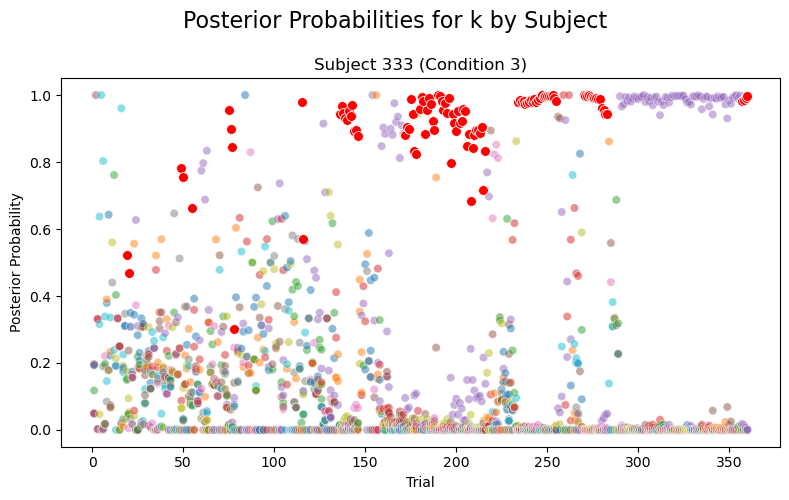

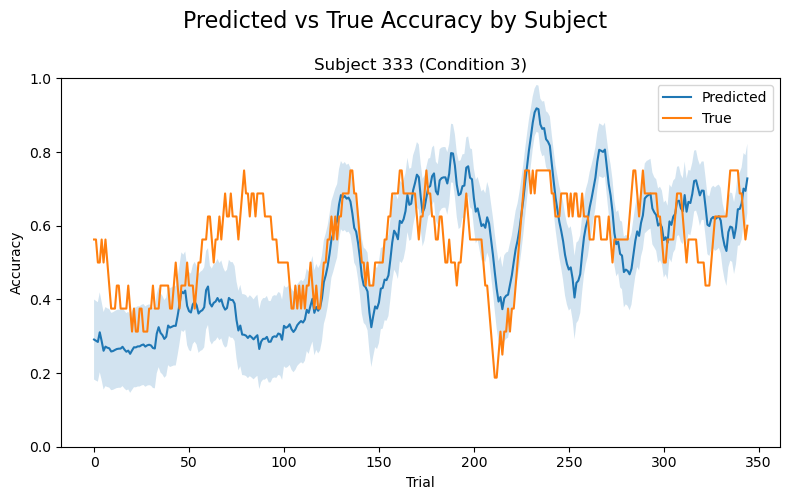

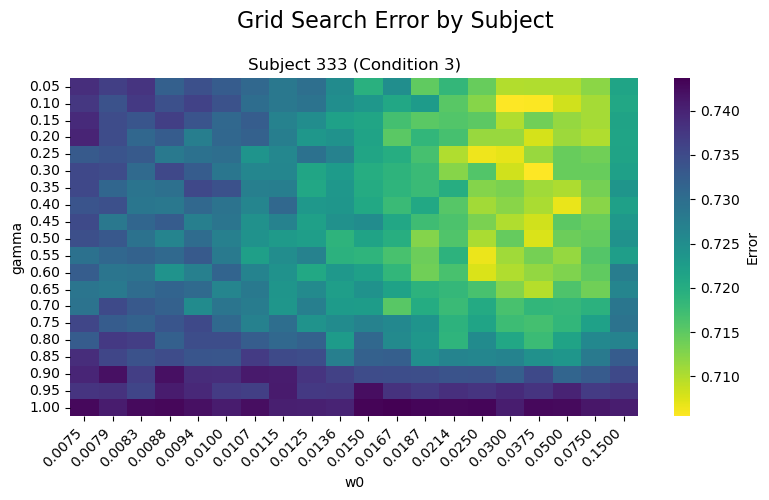

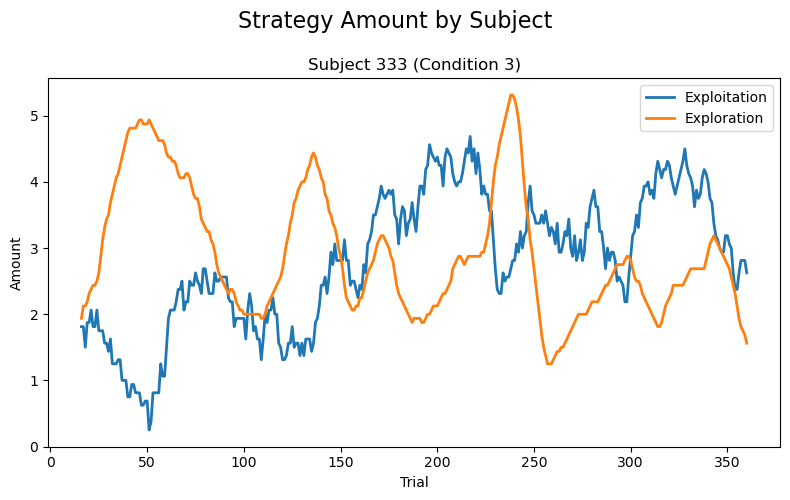

In [27]:
# plot posterior probabilities
model_eval = ModelEval()
model_eval.plot_posterior_probabilities(
    res, save_path=result_path/f'{model_name}_post.png')

# plot accuracy comparison
model_eval.plot_accuracy_comparison(prediction, save_path=result_path/f'{model_name}_acc.png')

# plot gamma and w0 grids
if model_name in ['M2_M', 'M4_PM', 'M6_MH', 'M7_PMH']:
    model_eval.plot_error_grids(res, fname=['gamma','w0'], save_path=result_path/f'{model_name}_grid.png')

# plot strategy amount dynamics
if model_name in ['M3_H', 'M5_PH', 'M6_MH', 'M7_PMH']:
    model_eval.plot_cluster_amount(res, window_size=16, save_path=result_path/f'{model_name}_amount.png')
    